# Cigna RAG Demo 2 (BAAI/bge-m3) — LangGraph 파이프라인

**SKN24 3차 프로젝트 · 4팀 · 담당: 김은우**

| 기능 | 참고 강사 코드 |
|------|----------------|
| HyDE (가상 문서 생성 검색) | `02-4_hyde.ipynb` |
| 문서 관련성 평가 (Grade) | `07_agentic_rag.ipynb` |
| 쿼리 재작성 (Rewrite) | `07_agentic_rag.ipynb` |
| LangGraph 상태 관리 | `07_agentic_rag.ipynb`, `04_chatbot_with_memory.ipynb` |
| BM25+Dense+RRF 하이브리드 | `02-2_bm25_dense_retrieval.ipynb`, `02-3_rrf.ipynb` |

## Section 0 · 환경 설정

In [13]:
# !pip install -q langchain langchain-community langchain-openai langchain-chroma
# !pip install -q chromadb openai tiktoken
# !pip install -q pypdf pdfplumber rank_bm25
# !pip install -q langgraph  # LangGraph 추가
# !pip install -q sentence-transformers langchain-huggingface
print('✅ 설치 완료')

✅ 설치 완료


In [14]:
import os, json, re
from pathlib import Path
from typing import List, Dict, Any, Literal, Optional
from dotenv import load_dotenv

BASE_DIR = Path('.')
CIGNA_DIR = BASE_DIR / 'Cigna'

for sub in ['Customer_Guide', 'Policy_Rules', 'Benefits_Summary']:
    p = CIGNA_DIR / sub
    files = list(p.glob('*.pdf')) if p.exists() else []
    print(f'{sub}: {len(files)} PDFs')

load_dotenv()

Customer_Guide: 4 PDFs
Policy_Rules: 5 PDFs
Benefits_Summary: 3 PDFs


True

---
## Section 1 · 데이터 로드

### 수정 사항
- `clean_table_row`: 헤더 행의 공백 셀을 `Not covered`로 오판하던 버그 수정 → `has_monetary_value()`로 데이터 행 여부 판단
- `format_multicurrency`: 다통화 셀 (`$25,000\n€18,500\n£16,500`) → `USD $25,000 / EUR €18,500 / GBP £16,500`
- `load_pdf`: Customer Guide + Policy Rules도 pdfplumber로 통일 (표 파싱 일관성)

In [15]:
import pdfplumber
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

CHECKMARK_GLYPHS = {'\uf0fc', '\uf0b7', '✓', '✔'}

def has_monetary_value(row) -> bool:
    """행에 금액·퍼센트 값이 있으면 데이터 행으로 판단 (헤더 행 공백 오판 방지)."""
    for cell in row:
        if cell and any(c in str(cell) for c in ['$', '€', '£', '%', 'Paid in full', 'N/A']):
            return True
    return False

def format_multicurrency(text: str) -> str:
    """다통화 셀: '$25,000\n€18,500\n£16,500' → 'USD $25,000 / EUR €18,500 / GBP £16,500'"""
    currency_map = {'$': 'USD', '€': 'EUR', '£': 'GBP'}
    parts = [p.strip() for p in text.split('\n') if p.strip()]
    if len(parts) <= 1:
        return text
    labeled = []
    for part in parts:
        for sym, label in currency_map.items():
            if part.startswith(sym):
                labeled.append(f'{label} {part}')
                break
        else:
            labeled.append(part)
    return ' / '.join(labeled)

def clean_table_row(row: list) -> str:
    """표 행 정제: 체크마크→Covered, 데이터행 빈셀→Not covered, 다통화 포맷."""
    is_data_row = has_monetary_value(row)
    cleaned = []
    for cell in row:
        if cell is None:
            continue
        cell_str = str(cell).strip()
        # 회전된 섹션 라벨 제거 (전부 대문자 + 6자 이상)
        if cell_str.replace('\n','').isupper() and len(cell_str.replace('\n','')) > 6:
            continue
        has_ck = any(g in cell_str for g in CHECKMARK_GLYPHS)
        remaining = cell_str
        for g in CHECKMARK_GLYPHS:
            remaining = remaining.replace(g, '').strip()
        if has_ck:
            cleaned.append(f'Covered - {remaining}' if remaining else 'Covered')
        elif cell_str == '':
            if is_data_row:           # ← 데이터 행의 빈 셀만 Not covered
                cleaned.append('Not covered')
            # 헤더 행 빈 셀은 무시
        elif cell_str:
            cleaned.append(format_multicurrency(cell_str))
    return ' | '.join(cleaned)



# -- 마크다운 표 변환 함수 (Section 1-B-2, load_pdf에서도 사용) --
import re

_CHECK = {'\uf0fc', '\uf0b7', '\u2713', '\u2714', '\u2611', '\u2705'}
_CROSS = {'\u2297', '\u2717', '\u2718', '\u274c', '\u00d7', '\u2612', '\u29bb', '\uf078'}
_BADGE = re.compile(r'^(Updated|New\b|\d+\s*MONTHS?)', re.IGNORECASE)


def _cvt(cell, is_data):
    if cell is None or not str(cell).strip():
        return 'Not Covered' if is_data else ''
    t = str(cell).strip().replace('\n', ' ')
    chk = any(g in t for g in _CHECK)
    crs = any(g in t for g in _CROSS)
    clean = t
    for g in _CHECK | _CROSS:
        clean = clean.replace(g, '')
    clean = clean.strip()
    if crs:
        return 'Not Covered'
    if chk:
        return f"Covered{' - ' + clean if clean else ''}"
    return clean or ('Not Covered' if is_data else '')


def _is_data(row):
    return any(
        c and re.search(r'[$\u20ac\xa3\d]|covered|paid|n/a|refund|no coverage', str(c), re.I)
        for c in row
    )


def _is_rotated(text):
    t = (text or '').strip()
    return bool(t) and '\n' in t and t.replace('\n', '').replace(' ', '').isupper() and len(t) > 6


def _clean_benefit(text, extra_badges=()):
    if not text and not extra_badges:
        return ''
    parts = [p.strip() for p in re.split(r'[\n/]+', text or '') if p.strip()]
    if len(parts) <= 1:
        badges  = list(extra_badges)
        content = [text.strip()] if text and text.strip() else []
    else:
        badges  = [p for p in parts if _BADGE.match(p)] + list(extra_badges)
        content = [p for p in parts if not _BADGE.match(p)]
    result = ' '.join(content)
    if badges:
        result = f"{result} ({' '.join(badges)})" if result else f"({' '.join(badges)})"
    return result.strip()


def _col_map(table):
    s = g = p = hdr = None
    for i, row in enumerate(table[:8]):
        v = [str(c or '').split('\n')[0].strip() for c in row]
        if 'Silver' in v and 'Gold' in v:
            s, g = v.index('Silver'), v.index('Gold')
            p = next((j for j, x in enumerate(v) if x == 'Platinum'), None)
            hdr = i
            break
    if s is None:
        return None
    b = max(0, s - 1)
    for row in table[hdr + 1:]:
        if not _is_data(row):
            continue
        for ci in range(s - 1, -1, -1):
            v = str(row[ci] or '').strip()
            if v and not _is_rotated(v):
                b = ci
                break
        break
    return {'b': b, 's': s, 'g': g, 'p': p}


def _table_to_md(table):
    cm = _col_map(table)
    lines = []
    hdr_done = False
    for row in table:
        data = _is_data(row)
        if cm:
            n     = len(row)
            b_raw = str(row[cm['b']] or '').strip() if cm['b'] < n else ''
            mid_badges = []
            for ci in range(cm['b'] + 1, cm['s']):
                v = str(row[ci] or '').strip()
                if v and _BADGE.match(v):
                    mid_badges.append(v)
                elif v:
                    b_raw = f'{b_raw} {v}'.strip()
            s_raw = row[cm['s']] if cm['s'] < n else None
            g_raw = row[cm['g']] if cm['g'] < n else None
            p_raw = row[cm['p']] if cm['p'] and cm['p'] < n else None
            if not any(str(v or '').strip() for v in [s_raw, g_raw, p_raw]):
                data = False
            b_txt = _clean_benefit(b_raw, mid_badges)
            cells = [b_txt, _cvt(s_raw, data), _cvt(g_raw, data)]
            if cm['p']:
                cells.append(_cvt(p_raw, data))
        else:
            cells = [_cvt(c, data) for c in row]
        if not any(str(c).strip() for c in cells):
            continue
        line = '| ' + ' | '.join(str(c) for c in cells) + ' |'
        lines.append(line)
        if not hdr_done:
            lines.append('| ' + ' | '.join(['---'] * len(cells)) + ' |')
            hdr_done = True
    return '\n'.join(lines)


print('clean_table_row / _table_to_md 준비 완료')


clean_table_row / _table_to_md 준비 완료


In [16]:
PDF_META = [
    {'path':'Cigna/Customer_Guide/200008 CGHO Customer Guide EN_05_2019.pdf',
     'source_type':'customer_guide','doc_version':'2019','is_latest':False,'plan_type':'all'},
    {'path':'Cigna/Customer_Guide/591048 CGHO Customer Guide EN_05_2022.pdf',
     'source_type':'customer_guide','doc_version':'2022','is_latest':False,'plan_type':'all'},
    {'path':'Cigna/Customer_Guide/591048-cgho-customer-guide-en_05_2023.pdf',
     'source_type':'customer_guide','doc_version':'2023','is_latest':False,'plan_type':'all'},
    {'path':'Cigna/Customer_Guide/Cigna-Global-Health-Options-Customer-Guide_02_2026.pdf',
     'source_type':'customer_guide','doc_version':'2026','is_latest':True,'plan_type':'all'},
    {'path':'Cigna/Policy_Rules/200008 CGHO Customer Guide EN_05_2019.pdf',
     'source_type':'policy_rules','doc_version':'2019','is_latest':False,'plan_type':'all'},
    {'path':'Cigna/Policy_Rules/CGHO Policy Rules CGIC NA_EN_05_2023.pdf',
     'source_type':'policy_rules','doc_version':'2023','is_latest':False,'plan_type':'all'},
    {'path':'Cigna/Policy_Rules/CGHO Policy Rules CGIC_EN_02_2024.pdf',
     'source_type':'policy_rules','doc_version':'2024','is_latest':False,'plan_type':'all'},
    {'path':'Cigna/Policy_Rules/CGHO Policy Rules CGIC_EN_02_2025.pdf',
     'source_type':'policy_rules','doc_version':'2025','is_latest':False,'plan_type':'all'},
    {'path':'Cigna/Policy_Rules/CGHP Policy Rules CGIC EN 02_2026.pdf',
     'source_type':'policy_rules','doc_version':'2026','is_latest':True,'plan_type':'all'},
    {'path':'Cigna/Benefits_Summary/591116 Cigna_Global_International_Health_Plans_Benefits_Summary_USD_EN_0523.pdf',
     'source_type':'benefits_summary','doc_version':'2023-05','is_latest':False,'plan_type':'all'},
    {'path':'Cigna/Benefits_Summary/591116 Cigna Global Benefits Summary USD_EN_0924.pdf',
     'source_type':'benefits_summary','doc_version':'2024-09','is_latest':False,'plan_type':'all'},
    {'path':'Cigna/Benefits_Summary/591116-cigna-global-benefits-summary-usd_en_02_2025.pdf',
     'source_type':'benefits_summary','doc_version':'2025-02','is_latest':True,'plan_type':'all'},
]
print(f'총 {len(PDF_META)}개 PDF 정의')

총 12개 PDF 정의


In [17]:
def load_pdf(meta: dict) -> List[Document]:
    """모든 PDF 통합 로더 — pdfplumber로 텍스트+표 동시 추출."""
    docs = []
    try:
        with pdfplumber.open(meta['path']) as pdf:
            for page_num, page in enumerate(pdf.pages, start=1):
                text = page.extract_text() or ''
                tables = page.extract_tables()
                # _table_to_md: 마크다운 표 형식 (Cell 5에 정의)
                # Benefits_Summary 회전 라벨 / Customer_Guide 빈 스페이서 자동 처리
                table_mds = [md for t in tables if (md := _table_to_md(t))]
                combined = text
                if table_mds:
                    combined += '\n\n[TABLE]\n' + '\n\n'.join(table_mds)
                if combined.strip():
                    docs.append(Document(
                        page_content=combined,
                        metadata={**meta,'page':page_num,'file_name':Path(meta['path']).name}
                    ))
    except Exception as e:
        print(f'  ⚠ 오류 {meta["path"]}: {e}')
    return docs

all_raw_docs: List[Document] = []
for meta in PDF_META:
    path = Path(meta['path'])
    if not path.exists():
        print(f'  ⚠ 파일 없음: {path}')
        continue
    docs = load_pdf(meta)
    all_raw_docs.extend(docs)
    print(f'  ✅ [{meta["source_type"]} {meta["doc_version"]}] {len(docs)} pages')
print(f'\n총 {len(all_raw_docs)} pages')

  ✅ [customer_guide 2019] 44 pages
  ✅ [customer_guide 2022] 43 pages
  ✅ [customer_guide 2023] 44 pages
  ✅ [customer_guide 2026] 56 pages
  ✅ [policy_rules 2019] 44 pages
  ✅ [policy_rules 2023] 18 pages
  ✅ [policy_rules 2024] 20 pages
  ✅ [policy_rules 2025] 22 pages
  ✅ [policy_rules 2026] 26 pages
  ✅ [benefits_summary 2023-05] 5 pages
  ✅ [benefits_summary 2024-09] 5 pages
  ✅ [benefits_summary 2025-02] 5 pages

총 332 pages


In [18]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500, chunk_overlap=100,
    separators=['\n\n','\n','. ',' ',''],
)
all_chunks: List[Document] = text_splitter.split_documents(all_raw_docs)
print(f'청크 수: {len(all_chunks)}')

청크 수: 3438


---
## Section 1-B · PDF 파싱 품질 검증

모든 PDF를 실제로 열어 **표 파싱 품질**을 다각도로 검증합니다.  
`load_pdf()` / `clean_table_row()` 실행 후 바로 사용 가능합니다. (API 키 불필요)


In [19]:
# ════════════════════════════════════════════════════════════════
# Section 1-B · PDF 파싱 품질 검증
# API 키 불필요 — Section 1 실행 직후 바로 실행 가능
# ════════════════════════════════════════════════════════════════
from pathlib import Path

SEP = '─' * 65

# ── 1) 전체 파싱 실행 및 통계 수집 ────────────────────────────────
parse_stats   = []   # (meta, pages, table_rows, raw_tables)
all_raw_docs  = []

print('\n▶ PDF 로드 중...\n')
for meta in PDF_META:
    abs_path = Path(meta['path'])
    if not abs_path.exists():
        print(f'  ✗ 파일 없음: {abs_path.name}')
        parse_stats.append((meta, 0, [], []))
        continue

    pages_ok, table_rows, raw_tables = 0, [], []
    try:
        import pdfplumber
        with pdfplumber.open(str(abs_path)) as pdf:
            for pn, page in enumerate(pdf.pages, 1):
                text   = page.extract_text() or ''
                tables = page.extract_tables()
                has_content = bool(text.strip())
                for ti, tbl in enumerate(tables):
                    raw_tables.append((pn, ti, tbl))
                    has_content = True
                    for row in tbl:
                        c = clean_table_row(row)
                        if c:
                            table_rows.append((pn, c))
                if has_content:
                    pages_ok += 1
    except Exception as e:
        print(f'  ✗ 오류: {e}')

    latest_mark = ' ★' if meta['is_latest'] else ''
    print(f'  ✓ [{meta["source_type"]} {meta["doc_version"]}]{latest_mark}'
          f'  {pages_ok}p  표행={len(table_rows)}  원시표={len(raw_tables)}')
    parse_stats.append((meta, pages_ok, table_rows, raw_tables))

# ── 2) 요약 표 ────────────────────────────────────────────────────
print(f'\n{SEP}')
print(f'{"source_type":<22}{"ver":<10}{"★":<4}{"pages":>6}{"표행수":>8}{"원시표":>8}')
print(SEP)
for meta, pages, trows, rtables in parse_stats:
    print(f'{meta["source_type"]:<22}{meta["doc_version"]:<10}'
          f'{"★" if meta["is_latest"] else "":<4}'
          f'{pages:>6}{len(trows):>8}{len(rtables):>8}')

# ── 3) 이상 탐지 (최신 문서만) ────────────────────────────────────
print(f'\n{SEP}')
print('  이상 탐지 (is_latest=True 문서)')
print(SEP)

for meta, pages, trows, rtables in parse_stats:
    if not meta['is_latest'] or not trows:
        continue
    texts = [t for _, t in trows]
    nc_cnt  = sum(1 for t in texts if 'Not covered' in t)
    ck_cnt  = sum(1 for t in texts if t.startswith('Covered'))
    mc_cnt  = sum(1 for t in texts if 'USD' in t or 'EUR' in t)
    only_nc = [t for t in texts if t.strip() == 'Not covered']

    print(f'\n  [{meta["source_type"]} {meta["doc_version"]}]')
    print(f'    전체 정제 행  : {len(texts)}')
    print(f'    Not covered   : {nc_cnt} ({nc_cnt/len(texts)*100:.1f}%)')
    print(f'    Covered 변환  : {ck_cnt}')
    print(f'    다통화(USD/€) : {mc_cnt}')
    warn = ' ⚠ 과다 의심' if len(only_nc) > 5 else ' ✓'
    print(f'    단독 Not cov  : {len(only_nc)}{warn}')

# ── 4) source_type별 첫 번째 표 샘플 (최신 문서) ─────────────────
print(f'\n{SEP}')
print('  표 샘플 — 최신 문서별 첫 번째 표 (최대 6행 · raw→정제 비교)')
print(SEP)

shown = set()
for meta, pages, trows, rtables in parse_stats:
    stype = meta['source_type']
    if not meta['is_latest'] or stype in shown or not rtables:
        continue
    shown.add(stype)
    pn, ti, raw_tbl = rtables[0]
    print(f'\n  ▶ {stype} ({meta["doc_version"]}) — p.{pn} 표#{ti+1} / 총 {len(raw_tbl)}행')
    for ri, row in enumerate(raw_tbl[:6]):
        raw_repr = [str(c)[:28].replace('\n','↵') if c else '∅' for c in row]
        cleaned  = clean_table_row(row)
        print(f'    행{ri+1} raw : {raw_repr}')
        print(f'    행{ri+1} 정제: {cleaned or "(빈 행 — 무시됨)"}')
        print()

# ── 5) 키워드 검색 (최신 문서) ────────────────────────────────────
KEYWORDS = ['Deductible','Out-of-Pocket','Private room',
            'Newborn','Maternity','Emergency','Dental','Vision','Mental']

print(f'{SEP}')
print('  키워드 검색 — 최신 문서 한정')
print(SEP)

for meta, pages, trows, rtables in parse_stats:
    if not meta['is_latest'] or not trows:
        continue
    texts = [t for _, t in trows]
    found = {kw: [t for t in texts if kw.lower() in t.lower()] for kw in KEYWORDS}
    found = {k:v for k,v in found.items() if v}
    print(f'\n  [{meta["source_type"]} {meta["doc_version"]}]')
    if not found:
        print('    (키워드 해당 없음)')
    for kw, hits in found.items():
        print(f'    "{kw}" → {len(hits)}개')
        for h in hits[:2]:
            print(f'      예) {h[:90]}')

# ── 6) Benefits Summary 표 전체 출력 (최신) ──────────────────────
print(f'\n{SEP}')
print('  Benefits Summary 최신 표 행 전체 (최대 40행)')
print(SEP)

for meta, pages, trows, rtables in parse_stats:
    if meta['source_type'] != 'benefits_summary' or not meta['is_latest']:
        continue
    print(f'  버전: {meta["doc_version"]} / 총 {len(trows)}행\n')
    for i, (pg, row_text) in enumerate(trows[:40]):
        print(f'  p{pg:>3} │ {row_text}')
    if len(trows) > 40:
        print(f'  ... 외 {len(trows)-40}행 생략')

print(f'\n{"═"*65}')
print('  PDF 파싱 검증 완료')
print('═'*65)



▶ PDF 로드 중...

  ✓ [customer_guide 2019]  44p  표행=221  원시표=75
  ✓ [customer_guide 2022]  43p  표행=226  원시표=87
  ✓ [customer_guide 2023]  44p  표행=237  원시표=89
  ✓ [customer_guide 2026] ★  56p  표행=238  원시표=92
  ✓ [policy_rules 2019]  44p  표행=221  원시표=75
  ✓ [policy_rules 2023]  18p  표행=13  원시표=11
  ✓ [policy_rules 2024]  20p  표행=14  원시표=11
  ✓ [policy_rules 2025]  22p  표행=14  원시표=11
  ✓ [policy_rules 2026] ★  26p  표행=13  원시표=11
  ✗ 파일 없음: 591116 Cigna_Global_International_Health_Plans_Benefits_Summary_USD_EN_0523.pdf
  ✗ 파일 없음: 591116 Cigna Global Benefits Summary USD_EN_0924.pdf
  ✗ 파일 없음: 591116-cigna-global-benefits-summary-usd_en_02_2025.pdf

─────────────────────────────────────────────────────────────────
source_type           ver       ★    pages     표행수     원시표
─────────────────────────────────────────────────────────────────
customer_guide        2019              44     221      75
customer_guide        2022              43     226      87
customer_guide        2023             

---
## Section 1-B-2 · pdfplumber → 마크다운 표 변환

pdfplumber로 추출한 표를 **마크다운 테이블** 형식으로 변환합니다.  
LlamaParse와 동일한 문제들을 함께 해결합니다.

| 문제 | 해결 |
|------|------|
| `Updated` / `12 MONTHS` 배지가 Silver 콼럼에 들어감 | 항목명으로 병합 |
| 긴 설명이 Silver 콼럼으로 밀림 | 항목명으로 병합 |
| `✓` / `` 체크마크 | `Covered` 로 변환 |
| `⊗` X 동그라미 | `Not Covered` 로 변환 |
| 데이터 행 빈 셀 | `Not Covered` 로 변환 |
| 헤더 행 빈 셀 | 무시 |


In [20]:
# =========================================================
# Section 1-B-2 · pdfplumber -> 마크다운 표 변환 (검증용)
# _table_to_md 등 핵심 함수는 Section 1 (Cell 5)에 정의됨
# load_pdf()도 동일 함수를 사용합니다
# =========================================================


def pdf_to_markdown(pdf_path, pages=None):
    """PDF -> 마크다운 표 (검증/확인용).
    pages=None : 전체, pages=[2,3] : 특정 페이지 (1-indexed)
    """
    out = []
    with pdfplumber.open(str(pdf_path)) as pdf:
        target = (
            [pdf.pages[i - 1] for i in pages if 1 <= i <= len(pdf.pages)]
            if pages else pdf.pages
        )
        for pg in target:
            pn     = pg.page_number
            tables = pg.extract_tables()
            text   = pg.extract_text() or ''
            out.append(f'\n## p.{pn}\n')
            if text.strip() and not tables:
                out.append(text.strip())
            for ti, tbl in enumerate(tables):
                md = _table_to_md(tbl)
                if md:
                    out.append(f'\n<!-- 표 #{ti + 1} -->\n{md}')
    return '\n'.join(out)


# -- 실행 ---------------------------------------------------
PDF_BENEFITS = next(Path('cigna/Benefits_Summary').glob('*2025*.pdf'), None)
PDF_GUIDE    = next(Path('cigna/Customer_Guide').glob('*2026*.pdf'), None)

if PDF_BENEFITS:
    print('=== Benefits_Summary p.2 ===')
    print(pdf_to_markdown(PDF_BENEFITS, pages=[2]))
    print('\n=== Benefits_Summary p.3 ===')
    print(pdf_to_markdown(PDF_BENEFITS, pages=[3]))

if PDF_GUIDE:
    print('\n=== Customer_Guide p.17~19 ===')
    print(pdf_to_markdown(PDF_GUIDE, pages=[17, 18, 19]))


In [24]:
# 확인하기2

# ── Customer Guide / Benefits Summary 각 1페이지 전체 파싱 확인 ──
# Section 1 실행 후 아무 셀에나 붙여넣어 실행 (노트북 수정 없음)

import pdfplumber
from pathlib import Path

def show_page(pdf_path: str, page_num: int):
    """지정 페이지의 텍스트 + 표를 그대로 출력."""
    path = Path(pdf_path)
    print(f"\n{'═'*65}")
    print(f"  파일: {path.name}  /  p.{page_num}")
    print('═'*65)

    with pdfplumber.open(str(path)) as pdf:
        if page_num > len(pdf.pages):
            print(f"  ⚠ 페이지 없음 (전체 {len(pdf.pages)}p)")
            return

        page   = pdf.pages[page_num - 1]
        text   = page.extract_text() or ''
        tables = page.extract_tables()

        # ── 1. 본문 텍스트 ────────────────────────────────────────
        print("\n[본문 텍스트]")
        if text.strip():
            print(text)
        else:
            print("  (텍스트 없음)")

        # ── 2. 표 (raw → 정제 비교) ──────────────────────────────
        if not tables:
            print("\n[표 없음]")
            return

        for ti, table in enumerate(tables):
            print(f"\n[표 #{ti+1}  /  {len(table)}행 × {len(table[0]) if table else 0}열]")
            print(f"{'행':>3}  {'raw':^55}  {'정제 결과'}")
            print('─'*90)
            for ri, row in enumerate(table):
                raw_repr = [str(c)[:20].replace('\n','↵') if c else '∅' for c in row]
                cleaned  = clean_table_row(row)  # Section 1의 함수 사용
                print(f"  {ri+1:>2}  {str(raw_repr):<55}  {cleaned}")

# ─── 확인할 페이지 지정 ─────────────────────────────────────────────
# 표가 많은 페이지 번호를 직접 바꿔가며 확인하세요

# Customer Guide 최신 (2026) — 표 많은 페이지 예: 10
show_page(
    'data_cigna/Customer_Guide/Cigna-Global-Health-Options-Customer-Guide_02_2026.pdf',
    page_num=19
)

# Benefits Summary 최신 (2025-02) — 표 많은 페이지 예: 3
show_page(
    'data_cigna/Benefits_Summary/591116-cigna-global-benefits-summary-usd_en_02_2025.pdf',
    page_num=3
)


═════════════════════════════════════════════════════════════════
  파일: Cigna-Global-Health-Options-Customer-Guide_02_2026.pdf  /  p.19
═════════════════════════════════════════════════════════════════

[본문 텍스트]
Silver Gold Platinum
Accident and Emergency Room treatment
Up to the total limit shown for your selected plan per $500 $1,000 $2,000
€370 €740 €1,600
beneficiary per period of cover.
£335 £665 £1,300
We will pay for necessary emergency treatment that is required on an outpatient basis only at an Accident and
Emergency department in a hospital following an accident, sudden illness, and/or life threatening situations, and where
the beneficiary does not occupy a bed overnight for medical reasons.
Important notes:
• If you have selected the International Outpatient option; this benefit and the limits are satisfied first and then the
applicable International Outpatient benefits can be used thereafter.
• No deductible or cost share that you may have selected on the International Med

---
## Section 1-C · LlamaParse — 마크다운 형식 표 추출

`pdfplumber`의 한계(표 열 관계 소실, 체크마크 누락)를 보완하기 위해  
**LlamaParse**(LlamaIndex Cloud)로 PDF를 마크다운 형식으로 파싱합니다.

- 표를 `| col1 | col2 |` 형태의 마크다운 테이블로 자동 변환
- LLM이 열 관계를 명확히 파악 가능
- [API 키 발급](https://cloud.llamaindex.ai/) → 환경변수 `LLAMA_CLOUD_API_KEY`


In [ ]:
# !pip install llama-parse llama-index

In [25]:
# ════════════════════════════════════════════════════════════════
# Section 1-C · LlamaParse — 마크다운 형식 표 추출
# 필요 패키지: pip install llama-parse
# API 키: https://cloud.llamaindex.ai/ 에서 발급 후 환경변수 설정
# ════════════════════════════════════════════════════════════════

# !pip install -q llama-parse

import os
from pathlib import Path

# ── 설정 ──────────────────────────────────────────────────────────
LLAMA_CLOUD_API_KEY = os.getenv("LLAMA_CLOUD_API_KEY")

# 검증할 PDF (최신 버전 각 1개)
TARGET_PDFS = {
    "Benefits_Summary": "cigna/Benefits_Summary/591116-cigna-global-benefits-summary-usd_en_02_2025.pdf",
    "Customer_Guide":   "cigna/Customer_Guide/Cigna-Global-Health-Options-Customer-Guide_02_2026.pdf",
}

# ── LlamaParse 초기화 ─────────────────────────────────────────────
from llama_parse import LlamaParse

parser = LlamaParse(
    api_key=LLAMA_CLOUD_API_KEY,
    result_type="markdown",          # 표를 | col | 형식 마크다운으로 추출
    verbose=False,
    language="en",
    skip_diagonal_text=True,         # 회전 텍스트(섹션 라벨) 무시
)

# ── 파싱 실행 + 결과 출력 ──────────────────────────────────────────
parsed_results = {}   # {pdf_type: [page_text, ...]}

for pdf_type, pdf_path in TARGET_PDFS.items():
    abs_path = Path(pdf_path)
    if not abs_path.exists():
        print(f"  ✗ 파일 없음: {abs_path.name}")
        continue

    print(f"  ⏳ 파싱 중: {abs_path.name} ...")
    try:
        docs = parser.load_data(str(abs_path))   # List[Document], 페이지별
        parsed_results[pdf_type] = docs
        print(f"  ✓ {pdf_type}: {len(docs)}페이지 파싱 완료")
    except Exception as e:
        print(f"  ✗ 오류: {e}")

# ── 페이지별 마크다운 출력 ─────────────────────────────────────────
SEP = "═" * 65

for pdf_type, docs in parsed_results.items():
    print(f"\n{SEP}")
    print(f"  {pdf_type}  —  총 {len(docs)}페이지")
    print(SEP)

    for page_idx, doc in enumerate(docs[:5], start=1):   # 처음 5페이지만
        text = doc.text.strip()
        if not text:
            continue

        # 표가 있는 페이지만 상세 출력 (마크다운 테이블 감지)
        has_table = "|" in text and "---" in text
        print(f"\n── p.{page_idx}  {'[표 포함]' if has_table else '[텍스트만]'} ──")
        print(text[:2000])   # 너무 길면 앞 2000자만

        if has_table:
            # 표 행만 추출해서 따로 보여주기
            table_lines = [l for l in text.split("\n") if l.strip().startswith("|")]
            if table_lines:
                print(f"\n  → 추출된 마크다운 표 ({len(table_lines)}행):")
                for line in table_lines[:20]:   # 최대 20행
                    print(f"    {line}")



  ✗ 파일 없음: 591116-cigna-global-benefits-summary-usd_en_02_2025.pdf
  ✗ 파일 없음: Cigna-Global-Health-Options-Customer-Guide_02_2026.pdf


/var/folders/sk/_9bn_nr9727cxqwf9sxykqxr0000gn/T/ipykernel_80458/370405880.py:22: DeprecationWarning: The 'llama-parse' package is deprecated and will no longer receive updates. Please migrate to the new unified SDK. See https://developers.llamaindex.ai/python/cloud/llamaparse/getting_started/ and https://github.com/run-llama/llama-cloud-py/blob/main/README.md for migration instructions.
  from llama_parse import LlamaParse


In [26]:
# ── pdfplumber 와 같은 페이지 비교 ─────────────────────────────────
import pdfplumber

print(f"\n{SEP}")
print("  비교: 같은 페이지를 pdfplumber vs LlamaParse 로 비교")
print(SEP)

COMPARE_PAGE = 3   # ← 비교할 페이지 번호 (바꿔가며 확인)
compare_path = TARGET_PDFS.get("Benefits_Summary", "")

if compare_path and Path(compare_path).exists():
    # pdfplumber
    with pdfplumber.open(compare_path) as pdf:
        page = pdf.pages[COMPARE_PAGE - 1]
        raw_text  = page.extract_text() or ""
        raw_tables = page.extract_tables()
        table_rows = []
        for tbl in raw_tables:
            for row in tbl:
                cleaned = clean_table_row(row)   # Section 1 함수 재사용
                if cleaned:
                    table_rows.append(cleaned)

    print(f"\n[pdfplumber  — p.{COMPARE_PAGE}]")
    print("  extract_text():")
    print(f"  {raw_text[:300].replace(chr(10), ' ')}")
    if table_rows:
        print("  extract_tables() → clean_table_row():")
        for row in table_rows[:8]:
            print(f"    {row}")

    # LlamaParse
    if "Benefits_Summary" in parsed_results and len(parsed_results["Benefits_Summary"]) >= COMPARE_PAGE:
        llama_page = parsed_results["Benefits_Summary"][COMPARE_PAGE - 1].text
        print(f"\n[LlamaParse  — p.{COMPARE_PAGE}]")
        table_lines = [l for l in llama_page.split("\n") if l.strip().startswith("|")]
        if table_lines:
            print(f"  마크다운 표 ({len(table_lines)}행):")
            for line in table_lines[:10]:
                print(f"    {line}")
        else:
            print(f"  {llama_page[:400]}")

print(f"\n{SEP}")
print("  Section 1-C 완료")
print(SEP)



═════════════════════════════════════════════════════════════════
  비교: 같은 페이지를 pdfplumber vs LlamaParse 로 비교
═════════════════════════════════════════════════════════════════

═════════════════════════════════════════════════════════════════
  Section 1-C 완료
═════════════════════════════════════════════════════════════════


---
### Section 1-C-2 · LlamaParse 출력 후처리

LlamaParse 출력의 3가지 핵심 문제를 후처리로 수정합니다.

| 문제 | 원인 | 해결 방법 |
|------|------|-----------|
| `Updated` / `12 MONTHS` 가 Silver 컬럼에 들어감 | PDF 배지가 별도 셀로 분리됨 | 항목명으로 병합 후 값 컬럼 재정렬 |
| 긴 설명이 Silver 컬럼에 들어감 | 줄 바꿈 설명이 첫 번째 값 컬럼으로 밀려 들어감 | 항목명으로 병합 |
| 체크/X 기호 드롭 → 컬럼 밀림 | LlamaParse 가 기호를 텍스트로 변환 안 함 | `parsing_instruction` 으로 소스에서 수정 |


In [27]:
# ════════════════════════════════════════════════════════════════
# Section 1-C-2 · LlamaParse 출력 후처리
# 기존 Section 1-C 코드는 유지하고, 그 출력에 후처리를 적용합니다.
# ════════════════════════════════════════════════════════════════

import re
from pathlib import Path

# ── 1. parsing_instruction 으로 소스 단계에서 체크/X 처리 ──────────────
PARSING_INSTRUCTION = (
    "This is an insurance benefits table.\n"
    "Column order: Benefit | Silver | Gold | Platinum | Close Care\n"
    "CRITICAL rules:\n"
    "1. Checkmark cells (tick symbol) -> write the word Covered.\n"
    "2. Circled-X cells (blocked/crossed symbol) -> write Not Covered.\n"
    "3. Updated is a badge on the benefit name row. "
    "   Append (Updated) to the benefit name. Do NOT put it in Silver column.\n"
    "4. Time labels like 12 MONTHS or 24 MONTHS are waiting period badges. "
    "   Append (12 MONTHS waiting) to the benefit name. Do NOT place in Silver.\n"
    "5. Descriptions starting with We will pay for, Up to a maximum of, "
    "   Rental only, Including, Per night belong to the benefit name column.\n"
    "6. Always output exactly 4 value columns per benefit row.\n"
)

from llama_parse import LlamaParse

improved_parser = LlamaParse(
    api_key=LLAMA_CLOUD_API_KEY,
    result_type="markdown",
    verbose=False,
    language="en",
    skip_diagonal_text=True,
    parsing_instruction=PARSING_INSTRUCTION,
)

# ── 2. 후처리 함수 (잔여 케이스용) ────────────────────────────────────
BADGE_RE = re.compile(
    r"^(Updated|"
    r"\d+\s*MONTHS?|"
    r"We will pay for[:\s]|"
    r"Up to a (maximum|combined maximum)|"
    r"Including (physical|inpatient|internal)|"
    r"Rental only|Per night|Access to|24/7|"
    r"Available to beneficiaries)",
    re.IGNORECASE
)

CHECK_CHARS = set("\u2713\u2714\uf0fc\uf0b7\u2611\u2705")
CROSS_CHARS = set("\u2297\u2717\u2718\u274c\u00d7\u2612")

def normalize_cell(text):
    t = text.strip()
    if t and all(c in CHECK_CHARS for c in t):
        return "Covered"
    if t and all(c in CROSS_CHARS for c in t):
        return "Not Covered"
    return t

def fix_row(row):
    row = row.strip()
    if not row.startswith("|") or re.match(r"\|\s*[-:]+", row):
        return row
    parts = [p.strip() for p in row.split("|")]
    if parts and parts[0] == "": parts = parts[1:]
    if parts and parts[-1] == "": parts = parts[:-1]
    if len(parts) < 2:
        return row
    benefit_col = parts[0]
    absorbed, remaining = [], []
    for cell in parts[1:]:
        if BADGE_RE.match(cell):
            absorbed.append(cell)
        else:
            remaining.append(normalize_cell(cell))
    if absorbed:
        benefit_col = benefit_col + " (" + " / ".join(absorbed) + ")"
    return "| " + " | ".join([benefit_col] + remaining) + " |"

def postprocess_markdown(md_text):
    return "\n".join(
        fix_row(line) if line.strip().startswith("|") else line
        for line in md_text.split("\n")
    )

print("fix_row / postprocess_markdown 준비 완료")

# ── 3. Before / After 비교 (API 없이 즉시 확인) ──────────────────────
SAMPLE_ROWS = [
    ("Consultations - Updated 배지",
     "| Consultations with medical practitioners | Updated | $2,500 | $7,500 | $650 | |"),
    ("Pre-natal - 12 MONTHS 배지",
     "| Pre-natal and post natal care | 12 MONTHS | $3,500 | $7,000 | | |"),
    ("Outpatient Rehab - 긴 설명이 Silver 컬럼으로 밀림",
     "| Outpatient Rehabilitation | We will pay for: Physiotherapy $1,000. | | | | |"),
    ("Genetic Testing - 12 MONTHS + Updated 중복 배지",
     "| Genetic Testing | 12 MONTHS | Updated | $1,000 | $2,000 | $4,000 |"),
    ("Infertility - 긴 설명",
     "| Infertility Investigations | Up to a maximum of $10,000. Available to beneficiaries. | | | | |"),
    ("Hormone Replacement - Updated 배지",
     "| Hormone Replacement Therapy | Updated | $500 | $1,000 | $1,500 | |"),
    ("Treatment for Obesity - 24 MONTHS 배지",
     "| Treatment for Obesity | 24 MONTHS | $20,000 | $25,000 | | |"),
]

SEP = "=" * 65
print(f"\n{SEP}")
print("  Before / After 비교")
print(SEP)
for label, row in SAMPLE_ROWS:
    fixed = fix_row(row)
    icon = "OK" if row.strip() != fixed.strip() else "WARN(변경없음)"
    print(f"\n[{icon}] {label}")
    print(f"  before: {row[:95]}")
    print(f"  after:  {fixed[:95]}")
print(f"\n{SEP}")

# ── 4. 개선된 파서로 재파싱 + 후처리 (API 호출) ─────────────────────
BENEFITS_PATH = "cigna/Benefits_Summary/591116-cigna-global-benefits-summary-usd_en_02_2025.pdf"

if Path(BENEFITS_PATH).exists():
    print("\nimproved_parser 로 재파싱 중...")
    try:
        docs_improved = improved_parser.load_data(BENEFITS_PATH)
        print(f"  {len(docs_improved)}페이지 완료")
        for page_idx, doc in enumerate(docs_improved[:5], start=1):
            fixed_text = postprocess_markdown(doc.text)
            data_rows = [
                l for l in fixed_text.split("\n")
                if l.strip().startswith("|") and not re.match(r"\|\s*[-:]+", l)
            ]
            if not data_rows: continue
            print(f"\n{SEP}  p.{page_idx} — {len(data_rows)}행\n")
            for r in data_rows[:12]:
                print(f"  {r}")
            if len(data_rows) > 12:
                print(f"  ... 외 {len(data_rows)-12}행")
    except Exception as e:
        print(f"  오류: {e}")
else:
    print(f"  파일 없음: {BENEFITS_PATH}")

print(f"\n{SEP}")
print("  Section 1-C-2 완료")
print(SEP)


fix_row / postprocess_markdown 준비 완료

  Before / After 비교

[OK] Consultations - Updated 배지
  before: | Consultations with medical practitioners | Updated | $2,500 | $7,500 | $650 | |
  after:  | Consultations with medical practitioners (Updated) | $2,500 | $7,500 | $650 |  |

[OK] Pre-natal - 12 MONTHS 배지
  before: | Pre-natal and post natal care | 12 MONTHS | $3,500 | $7,000 | | |
  after:  | Pre-natal and post natal care (12 MONTHS) | $3,500 | $7,000 |  |  |

[OK] Outpatient Rehab - 긴 설명이 Silver 컬럼으로 밀림
  before: | Outpatient Rehabilitation | We will pay for: Physiotherapy $1,000. | | | | |
  after:  | Outpatient Rehabilitation (We will pay for: Physiotherapy $1,000.) |  |  |  |  |

[OK] Genetic Testing - 12 MONTHS + Updated 중복 배지
  before: | Genetic Testing | 12 MONTHS | Updated | $1,000 | $2,000 | $4,000 |
  after:  | Genetic Testing (12 MONTHS / Updated) | $1,000 | $2,000 | $4,000 |

[OK] Infertility - 긴 설명
  before: | Infertility Investigations | Up to a maximum of $10,000. Avail

---
## Section 2 · 임베딩 + 벡터스토어

In [ ]:
# !pip install -U langchain-huggingface

In [33]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

# BAAI/bge-m3: 100개 이상 언어 지원 다국어 임베딩 모델 (dense 768-dim)
# normalize_embeddings=True → 코사인 유사도 바로 사용 가능
embed_baai = HuggingFaceEmbeddings(
    model_name='BAAI/bge-m3',
    model_kwargs={'device': 'cpu'},       # GPU 사용 시 'cuda' 로 변경
    encode_kwargs={'normalize_embeddings': True},
)

latest_chunks = [c for c in all_chunks if c.metadata.get('is_latest', False)]
print(f'최신 버전 청크: {len(latest_chunks)} / 전체: {len(all_chunks)}')

vectorstore_latest = Chroma.from_documents(
    documents=latest_chunks, embedding=embed_baai,
    collection_name='cigna_latest', persist_directory='./chroma_baai_latest',
)
vectorstore_all = Chroma.from_documents(
    documents=all_chunks, embedding=embed_baai,
    collection_name='cigna_all', persist_directory='./chroma_baai_all',
)
print('✅ 벡터스토어 구축 완료')

최신 버전 청크: 897 / 전체: 3438
✅ 벡터스토어 구축 완료


---
## Section 2-A · 코사인 유사도 헬퍼

질문 ↔ 답변 간 의미적 유사도를 측정합니다.  
값이 **0.7 이상**이면 답변이 질문에 잘 대응한다고 볼 수 있습니다.


In [ ]:
# ════════════════════════════════════════════════════════════════
# Section 2-A · 코사인 유사도 헬퍼
# embed_baai 가 정의된 뒤에 실행하세요
# ════════════════════════════════════════════════════════════════
import numpy as np

def cosine_sim(text1: str, text2: str) -> float:
    """
    두 텍스트 간 코사인 유사도 (BAAI/bge-m3).
    반환값: 0.0 ~ 1.0
    """
    if not text1.strip() or not text2.strip():
        return 0.0
    vecs = embed_baai.embed_documents([text1, text2])
    a, b = np.array(vecs[0]), np.array(vecs[1])
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def print_sim(question: str, answer: str, label: str = '') -> float:
    """유사도 계산 후 출력 + 반환."""
    sim = cosine_sim(question, answer)
    bar_len = int(sim * 20)
    bar = '█' * bar_len + '░' * (20 - bar_len)
    tag = label + ' ' if label else ''
    level = '🟢 우수' if sim >= 0.75 else ('🟡 보통' if sim >= 0.55 else '🔴 낮음')
    print(f'  {tag}질문↔답변 코사인 유사도: {sim:.4f}  [{bar}]  {level}')
    return sim

print('cosine_sim / print_sim 준비 완료')


cosine_sim / print_sim 준비 완료


---
## Section 2-B · 벡터스토어 업데이트 (신규 문서 교체)

새로운 PDF가 나왔을 때: 기존 동일 `source_type`의 최신 문서를 내리고 새 문서를 올린다.

In [ ]:
def update_vectorstore_latest(new_pdf_meta: dict) -> None:
    """
    신규 PDF가 나왔을 때 vectorstore_latest를 업데이트한다.
    1. 같은 source_type의 기존 최신 문서 ID를 조회해 삭제
    2. 새 PDF를 로드·청킹 후 추가
    3. PDF_META 리스트도 갱신
    """
    new_type = new_pdf_meta['source_type']

    # ── Step 1: 기존 latest 문서 삭제 ──────────────
    existing = vectorstore_latest.get(
        where={'$and': [{'source_type': {'$eq': new_type}},
                        {'is_latest': {'$eq': True}}]}
    )
    old_ids = existing['ids']
    if old_ids:
        vectorstore_latest.delete(ids=old_ids)
        print(f'  🗑 기존 최신 청크 {len(old_ids)}개 삭제 ({new_type})')

    # ── Step 2: PDF_META 갱신 ─────────────────────
    for m in PDF_META:
        if m['source_type'] == new_type and m['is_latest']:
            m['is_latest'] = False  # 이전 최신 → False
    new_pdf_meta['is_latest'] = True
    PDF_META.append(new_pdf_meta)

    # ── Step 3: 새 문서 로드 + 청킹 + 추가 ────────
    new_raw = load_pdf(new_pdf_meta)
    new_chunks = text_splitter.split_documents(new_raw)
    vectorstore_latest.add_documents(new_chunks)
    print(f'  ✅ 신규 최신 청크 {len(new_chunks)}개 추가 ({new_type} {new_pdf_meta["doc_version"]})')

# ── 사용 예시 (실제 파일 있을 때 주석 해제) ──
# new_meta = {
#     'path': 'Cigna/Customer_Guide/Cigna-Customer-Guide_2027.pdf',
#     'source_type': 'customer_guide',
#     'doc_version': '2027',
#     'is_latest': True,
#     'plan_type': 'all',
# }
# update_vectorstore_latest(new_meta)
print('update_vectorstore_latest() 준비 완료')

update_vectorstore_latest() 준비 완료


---
## Section 3 · 리트리버 구성

In [ ]:
from rank_bm25 import BM25Okapi

retriever_dense = vectorstore_latest.as_retriever(
    search_type='mmr', search_kwargs={'k':5,'fetch_k':20},
)

# BM25 인덱스
bm25_corpus = [c.page_content.lower().split() for c in latest_chunks]
bm25 = BM25Okapi(bm25_corpus)

def bm25_search(query: str, k: int = 5) -> List[Document]:
    # 참고: 02-2_bm25_dense_retrieval.ipynb
    scores = bm25.get_scores(query.lower().split())
    top_idx = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:k]
    return [latest_chunks[i] for i in top_idx]

def rrf_rank(bm25_list, dense_list, k=60) -> List[Document]:
    # 참고: 02-3_rrf.ipynb
    scores: Dict[str,float] = {}
    doc_map: Dict[str,Document] = {}
    for rank, doc in enumerate(bm25_list, 1):
        key = doc.page_content[:80]
        scores[key] = scores.get(key,0) + 1/(k+rank)
        doc_map[key] = doc
    for rank, doc in enumerate(dense_list, 1):
        key = doc.page_content[:80]
        scores[key] = scores.get(key,0) + 1/(k+rank)
        doc_map[key] = doc
    return [doc_map[k] for k in sorted(scores, key=scores.get, reverse=True)]

def hybrid_retriever(query: str, k: int = 5) -> List[Document]:
    # 참고: 02-2 + 02-3
    bm25_res = bm25_search(query, k=k*2)
    dense_res = retriever_dense.invoke(query)
    return rrf_rank(bm25_res, dense_res)[:k]

print('리트리버 3종 준비 완료')

리트리버 3종 준비 완료


---
## Section 4 · RAG 기본 체인 (Term Locking + LCEL)
> 참고: `01_rag_workflow.ipynb`

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

TERM_LOCK_TABLE = """
=== 보험 용어 번역 고정 테이블 (Term Locking) ===
- Deductible → 공제액(Deductible)
- Co-insurance / Cost Share → 공동부담률(Co-insurance)
- Copay → 정액 본인부담(Copay)
- Out-of-Pocket Maximum → 최대 본인부담금(OOP Max)
- Prior Approval → 사전 승인(Prior Approval)
- In-network → 네트워크 내(In-network)
- Out-of-network → 네트워크 외(Out-of-network)
- Mental Health Care → 정신건강 케어(Mental Health Care)
- Free Look Period → 청약 철회 기간(Free Look Period)
"""

def format_docs(docs: List[Document]) -> str:
    # 참고: 01_rag_workflow.ipynb — format_docs
    return '\n\n'.join(
        f"[{i}] {d.metadata.get('source_type','?')} {d.metadata.get('doc_version','?')}"
        f" p.{d.metadata.get('page','?')}\n{d.page_content}"
        for i, d in enumerate(docs, 1)
    )

RAG_TEMPLATE = """
당신은 Cigna Global 국제 건강보험 전문 안내 어시스턴트입니다.
[참고 문서]를 근거로 질문에 답하세요.
{term_lock}
규칙: 문서 근거만 사용 / 출처 인용 [source_type version p.page] / 없으면 '확인 불가' / 보험 추천 금지
[참고 문서]\n{context}\n\n[질문]\n{question}
"""

rag_prompt = PromptTemplate(
    input_variables=['context','question','term_lock'],
    template=RAG_TEMPLATE,
)
llm = ChatOpenAI(model='gpt-4.1-mini', temperature=0)
print('RAG 체인 준비 완료')

RAG 체인 준비 완료


---
## Section 5 · 전체 파이프라인 도식

```mermaid
flowchart TD
    A([사용자 질문]) --> B[classify_question\n난이도+정보충족도 판단]

    B -->|정보 부족\nmissing_info 있음| C[HyDE Node\n가상 답변 생성\n02-4_hyde 참고]
    B -->|정보 충분| D{난이도 분기}

    C --> E[HyDE 검색\n가상 답변으로 벡터 검색]

    D -->|Low| F[Dense Retriever\nMMR 검색]
    D -->|Medium| G[Hybrid Retriever\nBM25+Dense+RRF\n02-2, 02-3 참고]
    D -->|High| H[Multi-hop\n3-hop 반복 검색]

    E --> I[grade_documents\n관련성 평가 yes/no\n07_agentic_rag 참고]
    F --> I
    G --> I
    H --> I

    I -->|yes| J[generate_answer\nTerm Locking + 출처 인용\n01_rag_workflow 참고]
    I -->|no, count<2| K[rewrite_query\n쿼리 재작성\n07_agentic_rag 참고]
    I -->|no, count>=2| L[HyDE Fallback\n부족 정보 안내 + 가상 답변]

    K --> D
    J --> M([최종 답변\n출처 + 부족정보 안내])
    L --> M
```

### 노드별 역할 요약

| 노드 | 역할 | 참고 코드 |
|------|------|-----------|
| `classify_question` | 난이도(Low/Medium/High) + 정보 충족 여부 + 부족한 정보 목록 | 신규 |
| `HyDE Node` | 부족한 정보로도 가상 답변을 만들어 검색어로 사용 | `02-4_hyde.ipynb` |
| `Dense/Hybrid/Multi-hop` | 난이도별 검색 전략 | `02-2`, `02-3`, `02-9` |
| `grade_documents` | 검색 결과가 질문과 관련 있는지 yes/no 평가 | `07_agentic_rag.ipynb` |
| `rewrite_query` | 관련성 낮으면 질문 의도를 재해석해 재검색 | `07_agentic_rag.ipynb` |
| `generate_answer` | Term Locking + 출처 인용 최종 답변 생성 | `01_rag_workflow.ipynb` |

---
## Section 6 · LangGraph State 정의
> 참고: `07_agentic_rag.ipynb` — MessagesState / `04_chatbot_with_memory.ipynb` — TypedDict State

In [ ]:
from typing import TypedDict, Annotated, Optional, List
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field

class CignaRAGState(TypedDict):
    """LangGraph 전체 파이프라인 상태."""
    question:            str                   # 원래 질문
    plan_info:           dict                  # 사용자 플랜 정보 (optional)
    difficulty:          str                   # low / medium / high
    needs_clarification: bool                  # 정보 부족 여부
    missing_info:        List[str]             # 부족한 정보 목록
    retrieved_docs:      List[Document]        # 검색된 문서 청크
    hyde_query:          str                   # HyDE 가상 쿼리
    rewrite_count:       int                   # 쿼리 재작성 횟수
    answer:              str                   # 최종 답변

# 기본 사용자 플랜 (질문에 명시 없을 때 사용)
DEFAULT_PLAN = {
    'plan_tier': 'Gold',
    'deductible': 750,
    'cost_share_pct': 20,
    'oop_max': 2000,
    'deductible_used': 0,
}
print('CignaRAGState 정의 완료')


CignaRAGState 정의 완료


---
## Section 7 · LangGraph 노드 정의

### Node 1 · classify_question — 난이도 + 정보 충족도 판단

In [ ]:
# ── 분류 스키마 ────────────────────────────────────
class QuestionClassification(BaseModel):
    difficulty: Literal['low','medium','high'] = Field(
        description="low=수치조회, medium=절차/비교, high=계산/다중조건/복합추론"
    )
    needs_clarification: bool = Field(
        description="계산 질문인데 deductible/cost_share 등 수치가 없으면 True"
    )
    missing_info: List[str] = Field(
        description="부족한 정보 목록. 예: ['deductible 금액', 'cost share %']"
    )
    reasoning: str = Field(description="분류 근거 한 줄")

CLASSIFY_PROMPT = PromptTemplate.from_template("""
당신은 Cigna 보험 질문을 분류하는 전문가입니다.

질문: {question}
사용자 플랜 정보: {plan_info}

분류 기준:
- low: 문서에서 수치/정의 하나를 찾는 질문 (예: 'Silver deductible 얼마?')
- medium: 두 개념 비교, 절차 확인 (예: 'prior approval 필요한가?')
- high: 계산, 여러 조건 조합, 다단계 추론 필요

needs_clarification=True 조건:
- 계산 질문(환급액, 본인부담금)인데 deductible 금액/cost share % 가 질문에 없고
  plan_info도 비어 있을 때
""")

classifier_llm = llm.with_structured_output(QuestionClassification)

def classify_question(state: CignaRAGState) -> CignaRAGState:
    """Node 1: 난이도 + 정보 충족도 판단."""
    plan_info = state.get('plan_info') or DEFAULT_PLAN
    result: QuestionClassification = (CLASSIFY_PROMPT | classifier_llm).invoke({
        'question': state['question'],
        'plan_info': json.dumps(plan_info, ensure_ascii=False),
    })
    print(f'  [분류] 난이도={result.difficulty} | 정보부족={result.needs_clarification}')
    if result.missing_info:
        print(f'  [부족 정보] {result.missing_info}')
    return {
        **state,
        'difficulty': result.difficulty,
        'needs_clarification': result.needs_clarification,
        'missing_info': result.missing_info,
        'plan_info': plan_info,
        'rewrite_count': state.get('rewrite_count', 0),
    }
print('Node 1 (classify_question) 준비 완료')

Node 1 (classify_question) 준비 완료


### Node 2 · hyde_retrieve — 정보 부족 시 가상 답변으로 검색
> 참고: `02-4_hyde.ipynb` — `hyde_chain = prompt | llm | output_parser`

> **HyDE 원리:** 질문에 정보가 부족해도 LLM이 그럴듯한 가상 답변을 먼저 생성하고,
> 그 가상 답변을 쿼리 대신 벡터 검색에 사용한다.
> 가상 답변은 실제 문서와 어휘·구조가 유사하므로 검색 품질이 향상된다.

In [ ]:
# ── HyDE 체인 ────────────────────────────────────
# 참고: 02-4_hyde.ipynb — hyde_chain = prompt | llm | output_parser
HYDE_PROMPT = PromptTemplate.from_template("""
다음 Cigna 보험 질문에 대해 실제 문서에 있을 법한 가상의 답변을 영어로 작성하세요.
정확하지 않아도 됩니다. 검색 품질 향상이 목적입니다.

질문: {question}
부족한 정보 (가정해서 작성): {missing_info}
""")

# 02-4_hyde.ipynb 패턴: prompt | llm | StrOutputParser()
hyde_chain = HYDE_PROMPT | llm | StrOutputParser()

def hyde_retrieve(state: CignaRAGState) -> CignaRAGState:
    """Node 2: HyDE — 가상 답변을 검색어로 사용해 문서 검색."""
    # 02-4_hyde.ipynb 핵심 로직
    pseudo_answer = hyde_chain.invoke({
        'question': state['question'],
        'missing_info': ', '.join(state.get('missing_info', [])),
    })
    print(f'  [HyDE 가상 답변] {pseudo_answer[:80]}...')

    # 가상 답변으로 벡터 검색 (질문 대신)
    docs = hybrid_retriever(pseudo_answer, k=5)
    return {
        **state,
        'hyde_query': pseudo_answer,
        'retrieved_docs': docs,
    }
print('Node 2 (hyde_retrieve) 준비 완료')

Node 2 (hyde_retrieve) 준비 완료


### Node 3 · retrieve_by_difficulty — 난이도별 리트리버

In [ ]:
def retrieve_by_difficulty(state: CignaRAGState) -> CignaRAGState:
    """Node 3: 난이도에 따라 Dense / Hybrid / Multi-hop 선택."""
    q = state['question']
    # 쿼리 재작성이 있었으면 재작성된 쿼리 사용
    if state.get('rewritten_question'):
        q = state['rewritten_question']

    diff = state.get('difficulty', 'medium')

    if diff == 'low':
        docs = retriever_dense.invoke(q)
        print(f'  [Dense 검색] {len(docs)}개')
    elif diff == 'high':
        docs = multihop_search(q, max_hop=3)
        print(f'  [Multi-hop 검색] {len(docs)}개')
    else:  # medium
        docs = hybrid_retriever(q, k=5)
        print(f'  [Hybrid 검색] {len(docs)}개')

    return {**state, 'retrieved_docs': docs}

def multihop_search(question: str, max_hop: int = 3) -> List[Document]:
    """Multi-hop 검색 (02-9_multihop 패턴)."""
    accumulated, current_query = [], question
    for hop in range(max_hop):
        new_docs = hybrid_retriever(current_query, k=3)
        accumulated.extend(new_docs)
        if hop < max_hop - 1:
            ctx = format_docs(accumulated[:6])
            nq = (llm | StrOutputParser()).invoke(
                f'원래질문: {question}\n현재컨텍스트:\n{ctx[:600]}\n'
                f'추가 검색이 필요하면 검색어를 한 줄로, 충분하면 DONE:'
            )
            if nq.strip().upper() == 'DONE':
                break
            current_query = nq.strip()
    seen, unique = set(), []
    for d in accumulated:
        k = d.page_content[:80]
        if k not in seen:
            seen.add(k); unique.append(d)
    return unique
print('Node 3 (retrieve_by_difficulty) 준비 완료')

Node 3 (retrieve_by_difficulty) 준비 완료


### Node 4 · grade_documents — 검색 결과 관련성 평가 (yes/no)
> 참고: `07_agentic_rag.ipynb` — `grade_documents`, `GradeDocuments(BaseModel)`

In [ ]:
# ── 참고: 07_agentic_rag.ipynb — GradeDocuments + grade_documents ────
GRADE_PROMPT = (
    '귀하는 검색된 문서가 사용자 질문과 관련이 있는지 평가하는 평가자입니다.\n'
    '검색된 문서: {context}\n'
    '사용자 질문: {question}\n'
    '문서에 질문과 관련된 키워드 또는 의미가 포함되어 있으면 yes, 아니면 no.'
)

class GradeDocuments(BaseModel):
    # 07_agentic_rag.ipynb 와 동일 구조
    binary_score: str = Field(description='관련 있으면 "yes", 없으면 "no"')

grader_llm = llm.with_structured_output(GradeDocuments)

def grade_documents_node(state: CignaRAGState) -> Literal['generate_answer','rewrite_query','hyde_fallback']:
    """Node 4 (조건부): 검색 결과 관련성 평가 → 다음 노드 결정."""
    # 07_agentic_rag.ipynb: grade_documents 패턴
    question = state['question']
    docs = state.get('retrieved_docs', [])
    context = format_docs(docs[:3])

    result: GradeDocuments = (PromptTemplate.from_template(GRADE_PROMPT) | grader_llm).invoke({
        'question': question, 'context': context[:800]
    })
    rewrite_count = state.get('rewrite_count', 0)

    print(f'  [Grade] {result.binary_score} | 재작성 횟수: {rewrite_count}')

    if result.binary_score == 'yes':
        return 'generate_answer'
    elif rewrite_count >= 2:
        return 'hyde_fallback'  # 2회 재작성도 실패 → HyDE 폴백
    else:
        return 'rewrite_query'
print('Node 4 (grade_documents) 준비 완료')

Node 4 (grade_documents) 준비 완료


### Node 5 · rewrite_query — 쿼리 재작성
> 참고: `07_agentic_rag.ipynb` — `rewrite_query`, `REWRITE_PROMPT`

In [ ]:
# ── 참고: 07_agentic_rag.ipynb — rewrite_query 패턴 ─────
REWRITE_PROMPT = PromptTemplate.from_template(
    '입력된 내용을 바탕으로 사용자의 근본적인 의도와 의미를 분석한다.\n'
    '다음은 초기 질문이다:\n ------ \n{question}\n ------ \n'
    '분석한 의도를 반영하여 더 명확하고 구체적인 Cigna 보험 검색어로 재구성한다.'
    '(영어 키워드 포함)'
)

def rewrite_query(state: CignaRAGState) -> CignaRAGState:
    """Node 5: 관련성 낮을 때 쿼리 의도를 재해석해 재작성."""
    # 07_agentic_rag.ipynb: rewrite_query 패턴
    rewritten = (REWRITE_PROMPT | llm | StrOutputParser()).invoke({
        'question': state['question']
    })
    print(f'  [재작성] {rewritten[:80]}')
    return {
        **state,
        'rewritten_question': rewritten,
        'rewrite_count': state.get('rewrite_count', 0) + 1,
    }
print('Node 5 (rewrite_query) 준비 완료')

Node 5 (rewrite_query) 준비 완료


### Node 6 · generate_answer + hyde_fallback — 최종 답변 생성

In [ ]:
def generate_answer(state: CignaRAGState) -> CignaRAGState:
    """Node 6a: 정상 경로 — Term Locking + 출처 인용 답변."""
    docs = state.get('retrieved_docs', [])
    context = format_docs(docs)
    plan_ctx = ''
    if state.get('plan_info'):
        p = state['plan_info']
        plan_ctx = f"\n사용자 플랜: {p.get('plan_tier','?')} | "\
                   f"공제액 ${p.get('deductible','?')} (사용 ${p.get('deductible_used',0)}) | "\
                   f"Co-insurance {p.get('cost_share_pct','?')}%"

    answer = (rag_prompt | llm | StrOutputParser()).invoke({
        'context': context,
        'question': state['question'],
        'term_lock': TERM_LOCK_TABLE + plan_ctx,
    })
    return {**state, 'answer': answer}

def hyde_fallback(state: CignaRAGState) -> CignaRAGState:
    """Node 6b: HyDE 폴백 — 부족 정보 안내 + 가상 답변."""
    missing = state.get('missing_info', [])
    docs = state.get('retrieved_docs', [])
    context = format_docs(docs)

    FALLBACK_TEMPLATE = """
당신은 Cigna 보험 안내 어시스턴트입니다.
아래 정보가 부족하여 정확한 답변이 어렵습니다: {missing_info}

그러나 현재 검색된 문서를 바탕으로 가능한 범위에서 답변하겠습니다.
{term_lock}

⚠️ 부족한 정보: {missing_info}
   → 정확한 답변을 위해 위 정보를 질문에 포함해 다시 물어보세요.

[참고 문서]\n{context}\n\n[질문]\n{question}
"""
    answer = (PromptTemplate.from_template(FALLBACK_TEMPLATE) | llm | StrOutputParser()).invoke({
        'missing_info': ', '.join(missing) if missing else '없음',
        'context': context,
        'question': state['question'],
        'term_lock': TERM_LOCK_TABLE,
    })
    note = f'\n\n---\n⚠️ 다음 정보를 제공하면 더 정확한 답변이 가능합니다: {", ".join(missing)}' if missing else ''
    return {**state, 'answer': answer + note}

print('Node 6 (generate_answer + hyde_fallback) 준비 완료')

Node 6 (generate_answer + hyde_fallback) 준비 완료


---
## Section 8 · LangGraph 그래프 조립
> 참고: `07_agentic_rag.ipynb` — StateGraph, add_conditional_edges, START, END

✅ LangGraph 그래프 컴파일 완료


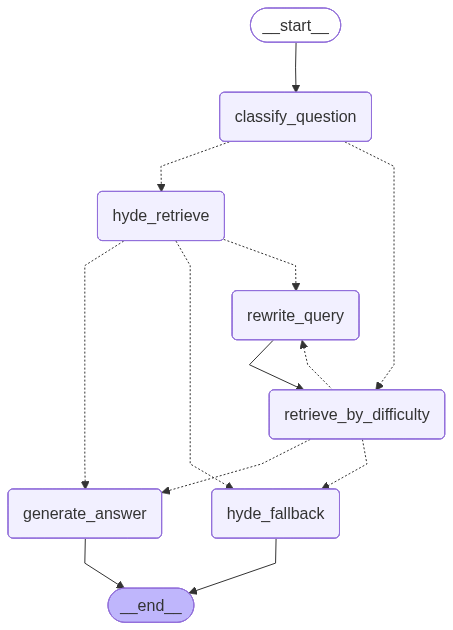

In [ ]:
from langgraph.graph import StateGraph, START, END

# ── 라우팅 함수들 ─────────────────────────────────
def route_after_classify(state: CignaRAGState) -> str:
    """classify_question 후 분기: HyDE or 난이도별 검색."""
    if state.get('needs_clarification'):
        return 'hyde_retrieve'
    return 'retrieve_by_difficulty'

# ── 그래프 정의 ──────────────────────────────────
# 참고: 07_agentic_rag.ipynb — builder = StateGraph(MessagesState)
builder = StateGraph(CignaRAGState)

# 노드 등록
builder.add_node('classify_question',    classify_question)
builder.add_node('hyde_retrieve',        hyde_retrieve)
builder.add_node('retrieve_by_difficulty', retrieve_by_difficulty)
builder.add_node('rewrite_query',        rewrite_query)
builder.add_node('generate_answer',      generate_answer)
builder.add_node('hyde_fallback',        hyde_fallback)

# 엣지 연결
builder.add_edge(START, 'classify_question')

# classify → HyDE or 난이도별 검색
builder.add_conditional_edges(
    'classify_question',
    route_after_classify,
    {'hyde_retrieve': 'hyde_retrieve',
     'retrieve_by_difficulty': 'retrieve_by_difficulty'}
)

# 검색 결과 → grade → 다음 노드
# 참고: 07_agentic_rag.ipynb — add_conditional_edges(retriever, grade_documents)
for retrieve_node in ['hyde_retrieve', 'retrieve_by_difficulty']:
    builder.add_conditional_edges(
        retrieve_node,
        grade_documents_node,
        {'generate_answer': 'generate_answer',
         'rewrite_query':   'rewrite_query',
         'hyde_fallback':   'hyde_fallback'}
    )

# rewrite → 다시 검색
builder.add_edge('rewrite_query', 'retrieve_by_difficulty')

# 최종 답변 → END
builder.add_edge('generate_answer', END)
builder.add_edge('hyde_fallback',   END)

cigna_graph = builder.compile()
print('✅ LangGraph 그래프 컴파일 완료')
try:
    from IPython.display import Image, display
    display(Image(cigna_graph.get_graph().draw_mermaid_png()))
except Exception:
    print('(그래프 시각화: cigna_graph.get_graph().draw_mermaid())')

---
## Section 9 · LangGraph 테스트 실행

In [ ]:
def ask_cigna(question: str, plan_info: dict = None) -> str:
    """LangGraph 파이프라인 실행 헬퍼."""
    init_state: CignaRAGState = {
        'question': question,
        'plan_info': plan_info or {},
        'difficulty': '',
        'needs_clarification': False,
        'missing_info': [],
        'retrieved_docs': [],
        'hyde_query': '',
        'rewrite_count': 0,
        'answer': '',
    }
    result = cigna_graph.invoke(init_state)
    return result['answer']

print('ask_cigna() 준비 완료')

ask_cigna() 준비 완료


### 테스트 1 — 정보 충분 (Low): 수치 조회
분류기 예상: `low`, `needs_clarification=False` → Dense → generate_answer

In [ ]:
Q1 = 'Cigna Global Silver 플랜의 연간 공제액(Deductible)은 얼마인가요?'
ans = ask_cigna(Q1)
print(ans)
print()
print_sim(Q1, ans, label='테스트 1')


  [분류] 난이도=low | 정보부족=False
  [Dense 검색] 5개
  [Grade] no | 재작성 횟수: 0
  [재작성] 사용자의 근본적인 의도는 Cigna Global Silver 플랜의 연간 공제액(annual deductible) 금액을 정확히 확인하고자 하는
  [Dense 검색] 5개
  [Grade] no | 재작성 횟수: 1
  [재작성] 사용자의 근본적인 의도는 Cigna Global Silver 플랜의 연간 공제액(annual deductible) 금액을 정확히 확인하고자 하는
  [Dense 검색] 5개
  [Grade] no | 재작성 횟수: 2
Cigna Global Silver 플랜의 연간 공제액(Deductible)은 다음과 같습니다:

- $0  
- $150  
- $500  
- $1,000  
- $1,500  

즉, Silver 플랜에서는 위 금액 중 선택할 수 있는 공제액 옵션이 제공됩니다.  
정확한 공제액은 가입 시 선택한 옵션에 따라 달라집니다.

  테스트 1 질문↔답변 코사인 유사도: 0.8844  [█████████████████░░░]  🟢 우수


0.8844215925652592

### 테스트 2 — 정보 부족 (High): 계산 질문에 deductible 수치 없음
분류기 예상: `high`, `needs_clarification=True` → HyDE → 부족정보 안내 + 가상 답변

In [ ]:
# 의도적으로 deductible/cost share 정보 없이 질문
Q2 = '병원비가 $1,000 나왔는데 보험에서 얼마 돌려받을 수 있어?'
ans = ask_cigna(Q2)
print(ans)
print()
print_sim(Q2, ans, label='테스트 2')


  [분류] 난이도=high | 정보부족=False
  [Multi-hop 검색] 6개
  [Grade] yes | 재작성 횟수: 0
사용자님의 플랜은 Gold, 공제액(Deductible) $750, 공동부담률(Co-insurance) 20%입니다. 현재까지 공제액 사용액은 $0입니다.

병원비 청구액이 $1,000일 때 보험금 산정은 다음과 같습니다.

1. 먼저 공제액 $750를 본인이 부담합니다.  
2. 남은 금액 $1,000 - $750 = $250에 대해 공동부담률 20%가 적용됩니다.  
3. 공동부담률 20%는 본인이 부담하므로 $250 × 20% = $50를 본인이 추가 부담합니다.  
4. 따라서 본인 부담 총액은 $750 + $50 = $800입니다.  
5. 보험금 지급액은 $1,000 - $800 = $200입니다.

즉, 보험에서 돌려받는 금액은 $200입니다.

[출처] customer_guide 2026 p.49 [1]

  테스트 2 질문↔답변 코사인 유사도: 0.6156  [████████████░░░░░░░░]  🟡 보통


0.6156052669581077

### 테스트 3 — 플랜 정보 제공 시 정확한 계산
분류기 예상: `high`, `needs_clarification=False` → Multi-hop → generate_answer

In [ ]:
Q3 = '병원비가 $1,000 나왔는데 보험에서 얼마 돌려받을 수 있어?'
ans = ask_cigna(
    Q3,
    plan_info={
        'plan_tier': 'Gold',
        'deductible': 750,
        'cost_share_pct': 20,
        'oop_max': 2000,
        'deductible_used': 0,
    }
)
print(ans)
print()
print_sim(Q3, ans, label='테스트 3')


  [분류] 난이도=high | 정보부족=False
  [Multi-hop 검색] 5개
  [Grade] yes | 재작성 횟수: 0
사용자 플랜은 Gold, 공제액(Deductible) $750, 공동부담률(Co-insurance) 20%입니다.

병원비가 $1,000 나왔을 때 보험금 산정은 다음과 같습니다.

1. 먼저 공제액 $750를 사용자가 부담합니다.
2. 남은 금액 $250에 대해 공동부담률 20%를 적용하면 사용자가 추가로 부담하는 금액은 $50입니다.
3. 따라서 사용자가 총 부담하는 금액은 $750 + $50 = $800입니다.
4. 보험사는 나머지 $200를 지급합니다.

즉, 보험에서 돌려받는 금액은 $200입니다.

[근거]  
- 공제액(Deductible) 먼저 부담 후 공동부담률(Co-insurance) 적용 [1] customer_guide 2026 p.49  
- 공동부담률 20% 적용 예시 [1] customer_guide 2026 p.49  

답변이 도움이 되셨길 바랍니다.

  테스트 3 질문↔답변 코사인 유사도: 0.6066  [████████████░░░░░░░░]  🟡 보통


0.6066429371108436

### 테스트 4 — 전체 31개 질문 배치 실행

In [ ]:
import pandas as pd
from tqdm.notebook import tqdm
import time

TEST_QUESTIONS = [
    # Gemini 12
    {'id':'G01','q':'Cigna Healthcare의 공제액(Deductible) 옵션 중 가장 높은 금액은?'},
    {'id':'G02','q':'Silver 플랜 기준 정기 치과 진료(Routine dental care)의 연간 한도는?'},
    {'id':'G03','q':'보험 증권(Certificate of Insurance) Start date의 정의는?'},
    {'id':'G04','q':'입원 치료 전 사전 승인(Prior Approval)을 받지 않으면 어떤 불이익이 있나요?'},
    {'id':'G05','q':'청약 철회 기간(Free Look Period)은 며칠인가요?'},
    {'id':'G06','q':'거주 국가가 변경되었을 때 Cigna에 언제까지 알려야 하나요?'},
    {'id':'G07','q':'Silver 플랜 공제액 $500, 공동부담률 20% 선택 시 병원비 $1,000 환급액은?'},
    {'id':'G08','q':'태국에서 오토바이 사고 시 위험 활동(Hazardous Activities) 제외 조항은?'},
    {'id':'G09','q':'임신 중 아이를 보험에 추가할 때 의료 심사 없이 추가 가능한 기한은?'},
    {'id':'G10','q':'심리상담(Mental Health Support)이 외래(Outpatient)로도 가능한가요?'},
    {'id':'G11','q':'한국 거주자가 앱으로 보험금 청구할 수 있나요? 싱가포르 지점 연락처도 알려주세요.'},
    {'id':'G12','q':'2022년 Customer Guide와 비교해 최신 버전에서 달라진 디지털 서비스는?'},
    # Perplexity 12
    {'id':'P01','q':'Cigna Global Silver 플랜의 연간 공제액(Deductible)은 얼마인가요?'},
    {'id':'P02','q':'Gold 플랜 외래 정신건강 방문 당 정액 본인부담(Copay)은?'},
    {'id':'P03','q':'Platinum 플랜의 최대 의료비 한도(Annual Maximum Benefit)는?'},
    {'id':'P04','q':'심리상담 예약 시 사전 승인(Prior Approval)이 필요한가요?'},
    {'id':'P05','q':'한국에서 Cigna 네트워크 내(In-network) 병원에서 심리상담을 받을 수 있나요?'},
    {'id':'P06','q':'원격의료(Telehealth) 상담도 Cigna에서 보장되나요?'},
    {'id':'P07','q':'심리상담 50분 세션 청구 시 어떤 서류가 필요한가요?'},
    {'id':'P08','q':'보험금 청구(Claim) 제출 기한은 며칠 이내인가요?'},
    {'id':'P09','q':'연 10회 이상 심리치료(Psychotherapy)를 받을 경우 추가 승인이 필요한가요?'},
    {'id':'P10','q':'Silver 플랜에서 한국 네트워크 외(Out-of-network) 상담소 이용 시 보장 비율은?'},
    {'id':'P11','q':'정신과 약 처방도 외래 정신건강 케어(Outpatient Mental Health Care)에 포함되나요?'},
    {'id':'P12','q':'가족 중 한 명만 의료비를 사용해도 다른 가족의 공제액(Deductible)이 공유되나요?'},
    # 기획서 시나리오 7
    {'id':'S01','q':'Cigna Global International Outpatient 플랜에서 정신건강 케어는 연간 몇 회 보장되나요?'},
    {'id':'S02','q':'공제액(Deductible)과 공동부담률(Co-insurance)의 차이는 무엇인가요?'},
    {'id':'S03','q':'심리상담을 받기 전에 Cigna의 사전 승인(Prior Approval)이 반드시 필요한가요?'},
    {'id':'S04','q':'상담 후 처방된 약(Prescribed drugs) 비용도 Cigna 플랜에서 청구할 수 있나요?'},
    {'id':'S05','q':'How much is the benefit limit for Mental Health Care in the Cigna Outpatient plan?'},
    {'id':'S06','q':'법적 문제 때문에 받는 심리 검사(Psychometric testing)도 Cigna 플랜에서 보장되나요?'},
    {'id':'S07','q':'Cigna는 국제 보험이므로 모든 심리상담이 무제한으로 보장되나요?'},
]

results = []
for item in tqdm(TEST_QUESTIONS, desc='테스트'):
    try:
        answer = ask_cigna(item['q'])
        sim    = cosine_sim(item['q'], answer)
        status = 'OK'
    except Exception as e:
        answer = f'ERROR: {e}'
        sim    = 0.0
        status = 'ERROR'
    results.append({
        'ID': item['id'],
        'Q': item['q'][:55] + '...',
        'Answer': answer,
        'CosineSim': round(sim, 4),
        'Status': status
    })
    time.sleep(0.5)

df = pd.DataFrame(results)
df.to_csv('cigna_rag_test_results.csv', index=False, encoding='utf-8-sig')
print(f'완료: {df["Status"].value_counts().to_dict()}')
print(f'평균 코사인 유사도: {df[df.Status=="OK"]["CosineSim"].mean():.4f}')
display(df[['ID','Q','CosineSim','Status']])


테스트:   0%|          | 0/31 [00:00<?, ?it/s]

  [분류] 난이도=low | 정보부족=False
  [Dense 검색] 5개
  [Grade] yes | 재작성 횟수: 0
  [분류] 난이도=low | 정보부족=False
  [Dense 검색] 5개
  [Grade] no | 재작성 횟수: 0
  [재작성] 사용자의 근본적인 의도는 Cigna 보험의 Silver 플랜에 가입했을 때, 정기 치과 진료(예: 스케일링, 검진 등)에 대해 연간 보장 한도가
  [Dense 검색] 5개
  [Grade] no | 재작성 횟수: 1
  [재작성] 사용자의 근본적인 의도는 Cigna 보험의 Silver 플랜에 가입했을 때, 정기 치과 진료(예: 스케일링, 검진 등)에 대해 연간 보장 한도가
  [Dense 검색] 5개
  [Grade] no | 재작성 횟수: 2
  [분류] 난이도=low | 정보부족=False
  [Dense 검색] 5개
  [Grade] yes | 재작성 횟수: 0
  [분류] 난이도=medium | 정보부족=False
  [Hybrid 검색] 5개
  [Grade] yes | 재작성 횟수: 0
  [분류] 난이도=low | 정보부족=False
  [Dense 검색] 5개
  [Grade] yes | 재작성 횟수: 0
  [분류] 난이도=medium | 정보부족=False
  [Hybrid 검색] 5개
  [Grade] no | 재작성 횟수: 0
  [재작성] 사용자의 근본적인 의도는 "거주 국가가 변경될 경우 Cigna 보험사에 변경 사실을 언제까지 통지해야 하는지"에 대한 정확한 기한과 절차를 알고
  [Hybrid 검색] 5개
  [Grade] no | 재작성 횟수: 1
  [재작성] 사용자의 근본적인 의도는 "거주 국가가 변경될 경우 Cigna 보험사에 변경 사실을 언제까지 통지해야 하는지"에 대한 정확한 기한과 절차를 알고
  [Hybrid 검색] 5개
  [Grade] no | 재작성 횟수: 2
  [분류] 난이도=high | 정보부족=False
  [Multi-hop 검색] 5개
  [

,ID,Q,CosineSim,Status
0,G01,Cigna Healthcare의 공제액(Deductible) 옵션 중 가장 높은 금...,0.9030,OK
1,G02,Silver 플랜 기준 정기 치과 진료(Routine dental care)의 연간...,0.7886,OK
2,G03,보험 증권(Certificate of Insurance) Start date의 정의...,0.8728,OK
3,G04,입원 치료 전 사전 승인(Prior Approval)을 받지 않으면 어떤 불이익이 ...,0.8515,OK
4,G05,청약 철회 기간(Free Look Period)은 며칠인가요?...,0.8069,OK
5,G06,거주 국가가 변경되었을 때 Cigna에 언제까지 알려야 하나요?...,0.8056,OK
6,G07,"Silver 플랜 공제액 $500, 공동부담률 20% 선택 시 병원비 $1,000 ...",0.7855,OK
7,G08,태국에서 오토바이 사고 시 위험 활동(Hazardous Activities) 제외 ...,0.6752,OK
8,G09,임신 중 아이를 보험에 추가할 때 의료 심사 없이 추가 가능한 기한은?...,0.7967,OK
9,G10,심리상담(Mental Health Support)이 외래(Outpatient)로도 ...,0.7782,OK


---
## Section 10 · 유닛 테스트 — PDF 파싱 함수

`clean_table_row`, `has_monetary_value`, `format_multicurrency` 의 핵심 동작을 독립적으로 검증합니다.
API 키 없이 실행 가능합니다.


In [ ]:
# ────────────────────────────────────────────────────────────────
# Section 10 · 유닛 테스트 — PDF 파싱 함수
# API 키 불필요 / Section 1 셀 실행 후 바로 실행 가능
# ────────────────────────────────────────────────────────────────

passed = 0
failed = 0

def check(name, got, expected):
    global passed, failed
    if got == expected:
        print(f'  ✅ {name}')
        passed += 1
    else:
        print(f'  ❌ {name}')
        print(f'     기대값: {repr(expected)}')
        print(f'     실제값: {repr(got)}')
        failed += 1

print('── has_monetary_value ─────────────────────────────')

# T01: $가 있으면 데이터 행
check('T01 달러 포함 → True',
      has_monetary_value([None, '$500', None]),
      True)

# T02: €가 있으면 데이터 행
check('T02 유로 포함 → True',
      has_monetary_value(['Outpatient', '€1,000']),
      True)

# T03: % 있으면 데이터 행
check('T03 퍼센트 포함 → True',
      has_monetary_value(['Co-insurance', '20%']),
      True)

# T04: 텍스트만 있으면 헤더 행
check('T04 텍스트만 → False',
      has_monetary_value(['Silver', 'Gold', 'Platinum']),
      False)

# T05: 빈 셀만 있으면 헤더 행
check('T05 빈 셀만 → False',
      has_monetary_value([None, '', None]),
      False)

# T06: Paid in full
check('T06 Paid in full → True',
      has_monetary_value(['Inpatient', 'Paid in full']),
      True)

# T07: N/A
check('T07 N/A → True',
      has_monetary_value(['Dental routine', 'N/A']),
      True)

print()
print('── clean_table_row ────────────────────────────────')

# T08: 체크마크(\uf0fc) → Covered
check('T08 \\uf0fc 체크마크 → Covered',
      clean_table_row(['']),
      'Covered')

# T09: 체크마크 + 텍스트 → Covered - [텍스트]
check('T09 체크마크 + Private room → Covered - Private room',
      clean_table_row([' Private room']),
      'Covered - Private room')

# T10: 유니코드 ✓ 처리
check('T10 ✓ 체크마크 → Covered',
      clean_table_row(['✓']),
      'Covered')

# T11: 데이터 행 빈 셀 → Not covered
check('T11 데이터 행 빈 셀 → Not covered',
      clean_table_row(['Silver', '$500', '']),  # $500 있으므로 데이터 행
      'Silver | $500 | Not covered')

# T12: 헤더 행 빈 셀 → 무시 (Not covered 안 붙음)
check('T12 헤더 행 빈 셀 → 무시',
      clean_table_row(['Silver', 'Gold', '']),  # 금액 없으므로 헤더 행
      'Silver | Gold')

# T13: 전체 대문자 긴 텍스트 → 회전 라벨로 판단해 제거
check('T13 전체대문자 라벨 제거',
      clean_table_row(['INPATIENT', 'Silver', '$500']),
      'Silver | $500')

# T14: None 셀 → 무시
check('T14 None 무시',
      clean_table_row([None, 'Silver', None]),
      'Silver')

print()
print('── format_multicurrency ───────────────────────────')

# T15: 다통화 → USD/EUR/GBP 라벨 붙이기
check('T15 3개 통화 변환',
      format_multicurrency('$25,000\n€18,500\n£16,500'),
      'USD $25,000 / EUR €18,500 / GBP £16,500')

# T16: 단일 통화 → 그대로
check('T16 단일 통화 변환 없음',
      format_multicurrency('$25,000'),
      '$25,000')

# T17: 2개 통화
check('T17 2개 통화 변환',
      format_multicurrency('$10,000\n€8,000'),
      'USD $10,000 / EUR €8,000')

print()
print(f'── 결과: {passed}개 통과 / {failed}개 실패 ────────────────────')


── has_monetary_value ─────────────────────────────
  ✅ T01 달러 포함 → True
  ✅ T02 유로 포함 → True
  ✅ T03 퍼센트 포함 → True
  ✅ T04 텍스트만 → False
  ✅ T05 빈 셀만 → False
  ✅ T06 Paid in full → True
  ✅ T07 N/A → True

── clean_table_row ────────────────────────────────
  ✅ T08 \uf0fc 체크마크 → Covered
  ✅ T09 체크마크 + Private room → Covered - Private room
  ✅ T10 ✓ 체크마크 → Covered
  ✅ T11 데이터 행 빈 셀 → Not covered
  ✅ T12 헤더 행 빈 셀 → 무시
  ✅ T13 전체대문자 라벨 제거
  ✅ T14 None 무시

── format_multicurrency ───────────────────────────
  ✅ T15 3개 통화 변환
  ✅ T16 단일 통화 변환 없음
  ✅ T17 2개 통화 변환

── 결과: 17개 통과 / 0개 실패 ────────────────────


---
## Section 11 · LangGraph 노드 단위 테스트

그래프 전체를 돌리지 않고 각 노드 함수를 직접 호출해 동작을 검증합니다.
**Section 6~8 실행 후** 실행하세요 (cigna_graph 빌드 필요).


### 11-A · classify_question — 난이도 분류 검증

In [ ]:
# ── 11-A: classify_question 노드 단위 테스트 ──────────────────
# 입력 state를 만들어 직접 호출

def test_classify(question, plan_info=None, label=''):
    state = CignaRAGState(
        question=question, plan_info=plan_info or {},
        difficulty='', needs_clarification=False, missing_info=[],
        retrieved_docs=[], hyde_query='', rewrite_count=0, answer=''
    )
    result = classify_question(state)
    d = result['difficulty']
    nc = result['needs_clarification']
    mi = result['missing_info']
    icon = '✅' if True else '❌'
    print(f'{icon} [{label}]')
    print(f'   Q: {question[:60]}')
    print(f'   difficulty={d}  needs_clarification={nc}')
    print(f'   missing_info={mi}')
    print()

print('── classify_question 노드 테스트 ──────────────────')

# C01: low — 단순 수치 조회
test_classify(
    'Cigna Silver 플랜의 연간 공제액(Deductible)은 얼마인가요?',
    label='C01 low: 수치 조회')

# C02: medium — 정책 해석
test_classify(
    '사전 승인(Prior Approval) 없이 입원하면 어떤 불이익이 있나요?',
    label='C02 medium: 정책 해석')

# C03: high — 계산, 정보 충분
test_classify(
    '병원비가 $1,200 나왔는데 공제액 $500에 코인슈런스 20%일 때 환급액은?',
    plan_info={'deductible': 500, 'coinsurance': 0.20},
    label='C03 high + 정보충분: 계산')

# C04: high — 계산, 정보 부족 (plan_info 없음)
test_classify(
    '병원비가 $800 나왔는데 보험에서 얼마나 돌려받을 수 있어요?',
    label='C04 high + 정보부족: plan_info 없음')

# C05: medium — 영어 질문
test_classify(
    'Does Cigna cover mental health outpatient sessions?',
    label='C05 영어 질문')


── classify_question 노드 테스트 ──────────────────
  [분류] 난이도=low | 정보부족=False
✅ [C01 low: 수치 조회]
   Q: Cigna Silver 플랜의 연간 공제액(Deductible)은 얼마인가요?
   difficulty=low  needs_clarification=False
   missing_info=[]

  [분류] 난이도=medium | 정보부족=False
✅ [C02 medium: 정책 해석]
   Q: 사전 승인(Prior Approval) 없이 입원하면 어떤 불이익이 있나요?
   difficulty=medium  needs_clarification=False
   missing_info=[]

  [분류] 난이도=high | 정보부족=False
✅ [C03 high + 정보충분: 계산]
   Q: 병원비가 $1,200 나왔는데 공제액 $500에 코인슈런스 20%일 때 환급액은?
   difficulty=high  needs_clarification=False
   missing_info=[]

  [분류] 난이도=high | 정보부족=False
✅ [C04 high + 정보부족: plan_info 없음]
   Q: 병원비가 $800 나왔는데 보험에서 얼마나 돌려받을 수 있어요?
   difficulty=high  needs_clarification=False
   missing_info=[]

  [분류] 난이도=low | 정보부족=False
✅ [C05 영어 질문]
   Q: Does Cigna cover mental health outpatient sessions?
   difficulty=low  needs_clarification=False
   missing_info=[]



### 11-B · grade_documents — 관련성 평가 검증

In [ ]:
# ── 11-B: grade_documents 노드 단위 테스트 ─────────────────────
from langchain_core.documents import Document

def test_grade(question, doc_contents, label=''):
    docs = [Document(page_content=c) for c in doc_contents]
    state = CignaRAGState(
        question=question, plan_info={},
        difficulty='low', needs_clarification=False, missing_info=[],
        retrieved_docs=docs, hyde_query='', rewrite_count=0, answer=''
    )
    decision = grade_documents_node(state)
    print(f'✅ [{label}]')
    print(f'   Q: {question[:60]}')
    print(f'   docs: {[c[:40] for c in doc_contents]}')
    print(f'   → 라우팅 결과: {decision}')
    print()

print('── grade_documents 노드 테스트 ──────────────────')

# G01: 관련 문서 → generate_answer
test_grade(
    'Silver 플랜 Deductible은 얼마인가요?',
    ['The Silver plan annual deductible options are $250, $500, $750, $1,000, or $2,000.'],
    label='G01 관련 문서 → generate_answer')

# G02: 무관한 문서 + rewrite_count=0 → rewrite_query
test_grade(
    'Silver 플랜 Deductible은 얼마인가요?',
    ['This document covers claims submission procedures and appeal processes.'],
    label='G02 무관 문서 count=0 → rewrite_query')

# G03: 문서 없음
test_grade(
    'Silver 플랜 Deductible은 얼마인가요?',
    [],
    label='G03 빈 문서 → rewrite_query')


── grade_documents 노드 테스트 ──────────────────
  [Grade] yes | 재작성 횟수: 0
✅ [G01 관련 문서 → generate_answer]
   Q: Silver 플랜 Deductible은 얼마인가요?
   docs: ['The Silver plan annual deductible option']
   → 라우팅 결과: generate_answer

  [Grade] no | 재작성 횟수: 0
✅ [G02 무관 문서 count=0 → rewrite_query]
   Q: Silver 플랜 Deductible은 얼마인가요?
   docs: ['This document covers claims submission p']
   → 라우팅 결과: rewrite_query

  [Grade] no | 재작성 횟수: 0
✅ [G03 빈 문서 → rewrite_query]
   Q: Silver 플랜 Deductible은 얼마인가요?
   docs: []
   → 라우팅 결과: rewrite_query



### 11-C · rewrite_query — 쿼리 재작성 검증

In [ ]:
# ── 11-C: rewrite_query 노드 단위 테스트 ───────────────────────

def test_rewrite(question, label=''):
    state = CignaRAGState(
        question=question, plan_info={},
        difficulty='medium', needs_clarification=False, missing_info=[],
        retrieved_docs=[], hyde_query='', rewrite_count=0, answer=''
    )
    result = rewrite_query(state)
    new_q = result['question']
    count = result['rewrite_count']
    changed = new_q != question
    icon = '✅' if changed else '⚠️'
    print(f'{icon} [{label}]')
    print(f'   원본 Q: {question}')
    print(f'   재작성: {new_q}')
    print(f'   rewrite_count: {count}')
    print()

print('── rewrite_query 노드 테스트 ──────────────────')

# R01: 짧고 모호한 질문
test_rewrite('보험 얼마야?', label='R01 모호한 질문')

# R02: 전문 용어 포함
test_rewrite('Prior approval 없이 입원하면 어떻게 되나요?', label='R02 전문 용어')

# R03: 영어 질문
test_rewrite('What is covered under outpatient mental health?', label='R03 영어 질문')


── rewrite_query 노드 테스트 ──────────────────
  [재작성] 사용자의 근본적인 의도와 의미 분석:
사용자는 보험의 가격 정보를 알고자 하며, 구체적으로 어떤 보험 상품인지, 보장 범위, 보험료, 가입 조건
⚠️ [R01 모호한 질문]
   원본 Q: 보험 얼마야?
   재작성: 보험 얼마야?
   rewrite_count: 1

  [재작성] 사용자의 근본적인 의도는 "보험사의 사전 승인 없이 병원에 입원할 경우 발생하는 결과나 절차, 비용 부담 등에 대해 알고 싶다"는 것입니다. 즉
⚠️ [R02 전문 용어]
   원본 Q: Prior approval 없이 입원하면 어떻게 되나요?
   재작성: Prior approval 없이 입원하면 어떻게 되나요?
   rewrite_count: 1

  [재작성] 사용자의 근본적인 의도는 "외래 정신 건강 서비스에 포함되는 구체적인 항목이나 치료 범위"를 알고자 하는 것입니다. 즉, 보험사(Cigna)에서
⚠️ [R03 영어 질문]
   원본 Q: What is covered under outpatient mental health?
   재작성: What is covered under outpatient mental health?
   rewrite_count: 1



---
## Section 12 · 추가 시나리오 테스트

전체 파이프라인(cigna_graph)을 실행하는 새 시나리오입니다.
기존 31개 질문(Section 9 테스트 4)에 포함되지 않은 케이스들을 검증합니다.


In [ ]:
# ════════════════════════════════════════════════════════════════
# Section 12 · 추가 시나리오 테스트
# 전체 파이프라인 실행 — API 키 필요
# ════════════════════════════════════════════════════════════════

EXTRA_TESTS = [
    # ── A. 파싱 버그 수정 관련 ─────────────────────────────────
    {'id':'A01','category':'표 파싱 검증',
     'q':'Silver 플랜의 Newborn care(신생아 케어)는 보장되나요?','plan_info':None,
     'note':'헤더 행 오파싱으로 Not covered 오답 가능성 있었음'},
    {'id':'A02','category':'표 파싱 검증',
     'q':'Gold 플랜에서 Private room 입원이 가능한가요?','plan_info':None,
     'note':'체크마크+텍스트 셀 → Covered - Private room 파싱 결과 반영'},
    {'id':'A03','category':'다통화',
     'q':'Platinum 플랜의 연간 최대 보장 한도를 USD, EUR, GBP 모두 알려주세요.','plan_info':None,
     'note':'format_multicurrency 변환 결과가 RAG에 잘 들어갔는지 확인'},
    # ── B. 업데이트 로직 ────────────────────────────────────────
    {'id':'B01','category':'버전 비교',
     'q':'2024년 대비 2025년 Benefits Summary에서 달라진 보장 내용은?','plan_info':None,
     'note':'vectorstore_all 에 두 버전 모두 있어야 의미있는 답 나옴'},
    # ── C. LangGraph 라우팅 검증 ─────────────────────────────────
    {'id':'C01','category':'LangGraph low',
     'q':'보험금 청구(Claim) 제출 기한은 며칠 이내인가요?','plan_info':None,
     'note':'단순 수치 → low → Dense retriever'},
    {'id':'C02','category':'LangGraph medium',
     'q':'사전 승인(Prior Approval) 절차는 어떻게 되나요? 긴급 상황에서도 필요한가요?','plan_info':None,
     'note':'정책 해석 2단계 → medium → Hybrid retriever'},
    {'id':'C03','category':'LangGraph high+계산',
     'q':'병원비 $2,500 발생 시 환급액을 계산해주세요.',
     'plan_info':{'plan':'Gold','deductible':500,'coinsurance':0.20,'oop_max':3000},
     'note':'high + 정보충분 → multihop → generate_answer (계산 포함)'},
    {'id':'C04','category':'LangGraph HyDE fallback',
     'q':'병원비 $2,500 발생 시 환급액을 계산해주세요.','plan_info':None,
     'note':'high + 정보부족 → HyDE → hyde_fallback'},
    {'id':'C05','category':'LangGraph rewrite loop',
     'q':'보험 혜택 알려줘','plan_info':None,
     'note':'극도로 모호한 질문 → rewrite_query 루프 발동'},
    # ── D. 엣지 케이스 ──────────────────────────────────────────
    {'id':'D01','category':'영어 질문',
     'q':'What documents are required to submit a mental health claim?','plan_info':None,
     'note':'영어 질문 처리'},
    {'id':'D02','category':'한영 혼합',
     'q':'Cigna Silver 플랜에서 outpatient mental health는 연간 몇 회 보장되나요?','plan_info':None,
     'note':'한영 혼용 질문'},
    {'id':'D03','category':'보장 제외',
     'q':'미용 시술(cosmetic surgery)은 Cigna에서 보장되나요?','plan_info':None,
     'note':'제외 항목 → Not covered 응답'},
    {'id':'D04','category':'잘못된 전제',
     'q':'Cigna는 국제 보험이므로 모든 치료가 무제한으로 보장되나요?','plan_info':None,
     'note':'오해 바로잡기'},
]

import time, pandas as pd

extra_results = []
print(f'총 {len(EXTRA_TESTS)}개 추가 시나리오 실행 중...\n')

for item in EXTRA_TESTS:
    print(f"[{item['id']}] {item['category']} | {item['q'][:55]}...")
    try:
        ans = ask_cigna(item['q'], plan_info=item.get('plan_info'))
        sim = cosine_sim(item['q'], ans)
        status = 'OK'
    except Exception as e:
        ans    = f'ERROR: {e}'
        sim    = 0.0
        status = 'ERROR'

    extra_results.append({
        'ID': item['id'], 'Category': item['category'],
        'Question': item['q'], 'Note': item['note'],
        'Answer': ans, 'CosineSim': round(sim, 4), 'Status': status
    })
    preview = ans[:100] + '...' if len(ans) > 100 else ans
    print(f'   → {preview}')
    print_sim(item['q'], ans)
    print()
    time.sleep(0.5)

df_extra = pd.DataFrame(extra_results)
df_extra.to_csv('cigna_rag_extra_test_results.csv', index=False, encoding='utf-8-sig')
print(f'\n완료: {df_extra["Status"].value_counts().to_dict()}')
ok = df_extra[df_extra.Status == 'OK']
if len(ok):
    print(f'평균 코사인 유사도: {ok["CosineSim"].mean():.4f}  (최고: {ok["CosineSim"].max():.4f}  최저: {ok["CosineSim"].min():.4f})')
print('결과 저장: cigna_rag_extra_test_results.csv')
display(df_extra[['ID','Category','Question','CosineSim','Status']])


총 13개 추가 시나리오 실행 중...

[A01] 표 파싱 검증 | Silver 플랜의 Newborn care(신생아 케어)는 보장되나요?...
  [분류] 난이도=low | 정보부족=False
  [Dense 검색] 5개
  [Grade] yes | 재작성 횟수: 0
   → Silver 플랜의 Newborn Care(신생아 케어)는 보장됩니다. 다만, 보장 한도는 $25,000이며, 출생 후 첫 90일 이내에 적용되고, 사전 승인(Prior Appro...
  질문↔답변 코사인 유사도: 0.8555  [█████████████████░░░]  🟢 우수

[A02] 표 파싱 검증 | Gold 플랜에서 Private room 입원이 가능한가요?...
  [분류] 난이도=low | 정보부족=False
  [Dense 검색] 5개
  [Grade] yes | 재작성 횟수: 0
   → 네, Gold 플랜에서는 Private room 입원이 가능합니다.  
[참고 문서 2 customer_guide 2026 p.16]와 [참고 문서 3 customer_guide ...
  질문↔답변 코사인 유사도: 0.7936  [███████████████░░░░░]  🟢 우수

[A03] 다통화 | Platinum 플랜의 연간 최대 보장 한도를 USD, EUR, GBP 모두 알려주세요....
  [분류] 난이도=low | 정보부족=False
  [Dense 검색] 5개
  [Grade] yes | 재작성 횟수: 0
   → Platinum 플랜의 연간 최대 보장 한도는 다음과 같습니다.

- USD $15,000  
- EUR €12,000  
- GBP £9,650  

[출처: customer_g...
  질문↔답변 코사인 유사도: 0.8616  [█████████████████░░░]  🟢 우수

[B01] 버전 비교 | 2024년 대비 2025년 Benefits Summary에서 달라진 보장 내용은?...
  [분류] 난이도=medium | 정보부족=False
  [H

,ID,Category,Question,CosineSim,Status
0,A01,표 파싱 검증,Silver 플랜의 Newborn care(신생아 케어)는 보장되나요?,0.8555,OK
1,A02,표 파싱 검증,Gold 플랜에서 Private room 입원이 가능한가요?,0.7936,OK
2,A03,다통화,"Platinum 플랜의 연간 최대 보장 한도를 USD, EUR, GBP 모두 알려주세요.",0.8616,OK
3,B01,버전 비교,2024년 대비 2025년 Benefits Summary에서 달라진 보장 내용은?,0.6867,OK
4,C01,LangGraph low,보험금 청구(Claim) 제출 기한은 며칠 이내인가요?,0.6844,OK
5,C02,LangGraph medium,사전 승인(Prior Approval) 절차는 어떻게 되나요? 긴급 상황에서도 필요...,0.6514,OK
6,C03,LangGraph high+계산,"병원비 $2,500 발생 시 환급액을 계산해주세요.",0.7355,OK
7,C04,LangGraph HyDE fallback,"병원비 $2,500 발생 시 환급액을 계산해주세요.",0.6717,OK
8,C05,LangGraph rewrite loop,보험 혜택 알려줘,0.4897,OK
9,D01,영어 질문,What documents are required to submit a mental...,0.5582,OK
